# Arunachal Pradesh: Growth, Inflation & Fiscal Health
**Financial Programming — Projects 1 & 2**

---

## Step 1 — Load All Packages

In [2]:
suppressPackageStartupMessages({
  library(readxl)
  library(strucchange)
  library(tempdisagg)
  library(sandwich)
  library(lmtest)
  library(ggplot2)
  library(dplyr)
  library(tidyr)
  library(zoo)
  library(scales)
  library(gridExtra)
})

BASE_DIR <- "c:/Users/user/Downloads/Python Env For Data Analysis/Financial Programming Project"
DATA_DIR <- file.path(BASE_DIR, "Data")
FIG_DIR  <- file.path(BASE_DIR, "figures")
TBL_DIR  <- file.path(BASE_DIR, "tables")
dir.create(FIG_DIR, showWarnings = FALSE, recursive = TRUE)
dir.create(TBL_DIR, showWarnings = FALSE, recursive = TRUE)

options(repr.plot.width = 12, repr.plot.height = 7, repr.plot.res = 150)

RESULTS <- list()

cat(sprintf("R version: %s\n", R.version.string))
cat(sprintf("strucchange: %s\n", packageVersion("strucchange")))
cat(sprintf("tempdisagg: %s\n", packageVersion("tempdisagg")))
cat(sprintf("ggplot2: %s\n", packageVersion("ggplot2")))

R version: R version 4.5.3 (2026-03-11 ucrt)
strucchange: 1.5.4
tempdisagg: 1.2.0
ggplot2: 4.0.2


### Helper Functions

In [3]:
month_to_num <- function(m) {
  if (is.numeric(m) || is.integer(m)) return(as.integer(m))
  mm <- c(January=1,February=2,March=3,April=4,May=5,June=6,
          July=7,August=8,September=9,October=10,November=11,December=12)
  as.integer(mm[trimws(as.character(m))])
}

assign_fy_quarter <- function(year, month) {
  if (is.na(year) || is.na(month)) return(c(NA_integer_, NA_integer_))
  year <- as.integer(year); month <- as.integer(month)
  if (month >= 4) {
    fy <- year
    q <- if (month <= 6) 1L else if (month <= 9) 2L else 3L
  } else {
    fy <- year - 1L; q <- 4L
  }
  c(fy, q)
}

fy_label <- function(fy) paste0(fy, "-", substr(as.character(fy+1), 3, 4))

# Best available value: Account > Revised > Budget
best_value <- function(acct, rev, bud) {
  ifelse(!is.na(acct), acct, ifelse(!is.na(rev), rev, bud))
}

## Step 2 — Load AR GSDP Constant Prices

In [4]:
gsdp_const_raw <- read_excel(file.path(DATA_DIR, "2011-12 Back Series - GSDP (Constant Prices) Arunachal Pradesh.xlsx"), skip=2)
gsdp_const <- gsdp_const_raw[grepl("^\\d{4}-\\d{4}$", gsdp_const_raw[[1]]), ]

cat(sprintf("Rows: %d | Cols: %d\n", nrow(gsdp_const), ncol(gsdp_const)))
cat("Column names:\n"); print(names(gsdp_const)[1:10])
cat(sprintf("First year: %s | Last year: %s\n", gsdp_const[[1]][1], gsdp_const[[1]][nrow(gsdp_const)]))
head(gsdp_const[, 1:5], 3)
tail(gsdp_const[, 1:5], 3)

Rows: 45 | Cols: 44
Column names:
 [1] "Year"                                        
 [2] "Agriculture and Allied Activities(Rs Lakh )" 
 [3] "Mining and Quarrying(Rs Lakh)"               
 [4] "Manufacturing(Rs Lakh)"                      
 [5] "Registered(Rs Lakh)"                         
 [6] "Unregistered(Rs Lakh)"                       
 [7] "Construction(Rs Lakh)"                       
 [8] "Electricity,Gas and Water supply(Rs Lakh)"   
 [9] "Transport Storage and Communication(Rs Lakh)"
[10] "Railways(Rs Lakh)"                           
First year: 1980-1981 | Last year: 2024-2025


Year,Agriculture and Allied Activities(Rs Lakh ),Mining and Quarrying(Rs Lakh),Manufacturing(Rs Lakh),Registered(Rs Lakh)
<chr>,<chr>,<chr>,<chr>,<chr>
1980-1981,108927,722,1700,NA
1981-1982,134477,2095,1832,NA
1982-1983,127751,1228,1976,NA


Year,Agriculture and Allied Activities(Rs Lakh ),Mining and Quarrying(Rs Lakh),Manufacturing(Rs Lakh),Registered(Rs Lakh)
<chr>,<chr>,<chr>,<chr>,<chr>
2022-2023,415752,46730,38797,NA
2023-2024,404177,43962,45351,NA
2024-2025,410258,50301,48666,NA


## Step 3 — Load AR GSDP Current Prices

In [5]:
gsdp_curr_raw <- read_excel(file.path(DATA_DIR, "2011-12 Back Series - GSDP (Current Prices) Arunachal Pradesh.xlsx"), skip=2)
gsdp_curr <- gsdp_curr_raw[grepl("^\\d{4}-\\d{4}$", gsdp_curr_raw[[1]]), ]

cat(sprintf("Rows: %d | Cols: %d\n", nrow(gsdp_curr), ncol(gsdp_curr)))
cat(sprintf("First year: %s | Last year: %s\n", gsdp_curr[[1]][1], gsdp_curr[[1]][nrow(gsdp_curr)]))
cat(sprintf("Both files have same %d years? %s\n", nrow(gsdp_const), nrow(gsdp_const)==nrow(gsdp_curr)))

Rows: 45 | Cols: 44
First year: 1980-1981 | Last year: 2024-2025
Both files have same 45 years? TRUE


## Step 4 — Load All-India GDP

In [6]:
gdp_india_raw <- read_excel(file.path(DATA_DIR, "AllindiaGDP.xlsx"))
# Drop unnamed columns
gdp_india_raw <- gdp_india_raw[, !grepl("^\\.{3}", names(gdp_india_raw))]

cat(sprintf("Rows: %d | Cols: %d\n", nrow(gdp_india_raw), ncol(gdp_india_raw)))
cat("Columns:", paste(names(gdp_india_raw), collapse=", "), "\n")
head(gdp_india_raw, 3)
tail(gdp_india_raw, 3)

Rows: 76 | Cols: 3
Columns: Year, GDP at Current Prices, GDPMP at Constant Prices 


Year,GDP at Current Prices,GDPMP at Constant Prices
<chr>,<dbl>,<dbl>
1950-51,10221.63,496848.1
1951-52,10863.35,511489.4
1952-53,10663.43,524919.5


Year,GDP at Current Prices,GDPMP at Constant Prices
<chr>,<dbl>,<dbl>
2023-24,30122956,17650591
2024-25,33068145,18796955
2025-26,35713886,20189919


## Step 5 — Load Per Capita NSDP (All States, Constant Prices)

In [7]:
# Row 2 = state names, Row 3 = headers, data from row 4
pcnsdp_raw <- read_excel(file.path(DATA_DIR, "2011-12 Back Series - Per Capita NSDP (Constant Prices) Arunachal Pradesh.xlsx"), col_names=FALSE)
state_names <- as.character(pcnsdp_raw[2, ])
state_names[1] <- "Year"

pcnsdp_data <- pcnsdp_raw[-(1:3), ]
names(pcnsdp_data) <- state_names
pcnsdp_data <- pcnsdp_data[grepl("^\\d{4}-", pcnsdp_data$Year), ]

# Standardize year and extract numeric
pcnsdp_data$num_year <- as.integer(substr(pcnsdp_data$Year, 1, 4))

# Find AR column
ar_col <- grep("Arunach", state_names, ignore.case=TRUE, value=TRUE)
cat("AR column name:", ar_col, "\n")
if (length(ar_col) > 0) pcnsdp_data$AR_pcnsdp <- as.numeric(pcnsdp_data[[ar_col[1]]])

cat(sprintf("States found: %d\n", length(state_names)-1))
cat("First 5 state names:", paste(state_names[2:6], collapse=", "), "\n")
cat(sprintf("Rows: %d | Year range: %s to %s\n", nrow(pcnsdp_data), pcnsdp_data$Year[1], pcnsdp_data$Year[nrow(pcnsdp_data)]))
cat("AR first non-NA:", min(pcnsdp_data$num_year[!is.na(pcnsdp_data$AR_pcnsdp)]), "\n")
head(pcnsdp_data[!is.na(pcnsdp_data$AR_pcnsdp), c("Year","AR_pcnsdp")], 3)
tail(pcnsdp_data[!is.na(pcnsdp_data$AR_pcnsdp), c("Year","AR_pcnsdp")], 3)

New names:
• `` -> `...1`
• `` -> `...2`
• `` -> `...3`
• `` -> `...4`
• `` -> `...5`
• `` -> `...6`
• `` -> `...7`
• `` -> `...8`
• `` -> `...9`
• `` -> `...10`
• `` -> `...11`
• `` -> `...12`
• `` -> `...13`
• `` -> `...14`
• `` -> `...15`
• `` -> `...16`
• `` -> `...17`
• `` -> `...18`
• `` -> `...19`
• `` -> `...20`
• `` -> `...21`
• `` -> `...22`
• `` -> `...23`
• `` -> `...24`
• `` -> `...25`
• `` -> `...26`
• `` -> `...27`
• `` -> `...28`
• `` -> `...29`
• `` -> `...30`
• `` -> `...31`
• `` -> `...32`
• `` -> `...33`
• `` -> `...34`


AR column name: ARUNACHAL PRADESH 
States found: 33
First 5 state names: ANDAMAN AND NICOBAR ISLANDS, ANDHRA PRADESH, ARUNACHAL PRADESH, ASSAM, BIHAR 
Rows: 65 | Year range: 1960-1961 to 2024-2025
AR first non-NA: 1970 


Year,AR_pcnsdp
<chr>,<dbl>
1970-1971,13426
1971-1972,13985
1972-1973,13749


Year,AR_pcnsdp
<chr>,<dbl>
2022-2023,106512
2023-2024,110766
2024-2025,120943


## Step 6 — Load State Finances

In [8]:
sf <- read_excel(file.path(DATA_DIR, "State Finances - Arunachal.XLSX"))
sf$Account <- as.numeric(sf$Account)
sf$Revised <- as.numeric(sf$Revised)
sf$Budget  <- as.numeric(sf$Budget)
sf$NumYear <- as.integer(substr(sf$`Fiscal Year`, 1, 4))
sf$BestValue <- best_value(sf$Account, sf$Revised, sf$Budget)

cat(sprintf("Dim: %d x %d\n", nrow(sf), ncol(sf)))
cat("Appendices:", paste(unique(sf$Appendix), collapse=", "), "\n")
cat(sprintf("Year range: %d to %d\n", min(sf$NumYear, na.rm=T), max(sf$NumYear, na.rm=T)))

key_heads <- c("Total: TOTAL REVENUE (I+II)",
  "I.B: Share in Central Taxes (i to ix)",
  "II.D: Grants from the Centre (1 to 7)",
  "Total: TOTAL EXPENDITURE (I+II+III)",
  "II.C.2: Interest Payments (i to iv)")
for (h in key_heads) {
  n <- sum(sf$`Budget Head` == h, na.rm=TRUE)
  cat(sprintf("  %-50s  rows: %d\n", h, n))
}

Dim: 12424 x 9
Appendices: Appendix-1, Appendix-2, Appendix-3, Appendix-4 
Year range: 1990 to 2025
  Total: TOTAL REVENUE (I+II)                         rows: 36
  I.B: Share in Central Taxes (i to ix)               rows: 36
  II.D: Grants from the Centre (1 to 7)               rows: 36
  Total: TOTAL EXPENDITURE (I+II+III)                 rows: 36
  II.C.2: Interest Payments (i to iv)                 rows: 36


## Step 7 — Load All-India CPI

In [9]:
cpi_india <- read_excel(file.path(DATA_DIR, "All India CPI Base Year 2012.xlsx"), sheet="CPI Index")
# Drop unnamed columns (columns 7-10 if they exist)
unnamed_cols <- grepl("^\\.{3}|^Unnamed", names(cpi_india))
if (any(unnamed_cols)) cpi_india <- cpi_india[, !unnamed_cols]

cat(sprintf("Dim: %d x %d\n", nrow(cpi_india), ncol(cpi_india)))
cat("Columns:", paste(names(cpi_india), collapse=", "), "\n")
cat("Unique months:", paste(sort(unique(cpi_india$Month)), collapse=", "), "\n")
cat(sprintf("Unique items: %d\n", length(unique(cpi_india$Item))))
print(unique(cpi_india$Item))

# Sample: January 2011
cat("\nJanuary 2011 sample:\n")
head(cpi_india[cpi_india$Month == 1 & cpi_india$Year == 2011, ], 3)

New names:
• `` -> `...7`
• `` -> `...8`
• `` -> `...9`
• `` -> `...10`


Dim: 4920 x 6
Columns: Year, Month, Item, Rural, Urban, Combined 
Unique months: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12 
Unique items: 28
 [1] "Cereals and products"                "Meat and fish"                      
 [3] "Egg"                                 "Milk and products"                  
 [5] "Oils and fats"                       "Fruits"                             
 [7] "Vegetables"                          "Pulses and products"                
 [9] "Sugar and confectionery"             "Spices"                             
[11] "Non-alcoholic beverages"             "Prepared meals; snacks; sweets etc."
[13] "Food and beverages"                  "Pan; tobacco; and intoxicants"      
[15] "Clothing"                            "Footwear"                           
[17] "Clothing and footwear"               "Housing"                            
[19] "Fuel and light"                      "Household goods and services"       
[21] "Health"                              "Transport

Year,Month,Item,Rural,Urban,Combined
<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
2011,1,Cereals and products,92.2,93.4,92.6
2011,1,Meat and fish,84.9,85.7,85.2
2011,1,Egg,92.6,99.2,95.2


### Load All-India Core Sheet (for inclusion method)

In [10]:
core_india_raw <- read_excel(file.path(DATA_DIR, "All India CPI Base Year 2012.xlsx"), sheet="Core")
cpi_india_weights <- read_excel(file.path(DATA_DIR, "All India CPI Base Year 2012.xlsx"), sheet="Weights")

cat(sprintf("Core sheet: %d rows\n", nrow(core_india_raw)))
cat("Core items:", paste(unique(core_india_raw$Item), collapse=", "), "\n")
head(core_india_raw, 3)

Core sheet: 540 rows
Core items: Clothing and footwear, Housing, Miscellaneous 


Year,Month,Item,Rural,Urban,Combined
<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
2011,1,Clothing and footwear,82.9,82.7,82.8
2011,1,Housing,NA,87.8,87.8
2011,1,Miscellaneous,87.9,89.2,88.5


## Step 8 — Load AR CPI

In [11]:
cpi_ar <- read_excel(file.path(DATA_DIR, "Arunachal CPI Base Year 2012.xlsx"), sheet="CPI Index")

cat(sprintf("Dim: %d x %d\n", nrow(cpi_ar), ncol(cpi_ar)))
cat("Columns:", paste(names(cpi_ar), collapse=", "), "\n")
cat("Unique months:", paste(head(unique(cpi_ar$Month),6), collapse=", "), "\n")
cat("Items:", paste(unique(cpi_ar$Description), collapse=", "), "\n")

# Non-null counts per column per item
cat("\nData availability (non-NA counts):\n")
for (item in unique(cpi_ar$Description)) {
  sub <- cpi_ar[cpi_ar$Description == item, ]; n <- nrow(sub)
  cat(sprintf("  %-35s Rural:%3d/%d | Urban:%3d/%d | Combined:%3d/%d\n",
    item, sum(!is.na(sub$Rural)),n, sum(!is.na(sub$Urban)),n, sum(!is.na(sub$Combined)),n))
}

Dim: 1058 x 6
Columns: Year, Month, Description, Rural, Urban, Combined 
Unique months: January, February, March, April, May, June 
Items: Food and beverages, Pan; tobacco; and intoxicants, Clothing and footwear, Fuel and light, Miscellaneous, General Index (All Groups) 

Data availability (non-NA counts):
  Food and beverages                  Rural:175/175 | Urban:  0/175 | Combined:  8/175
  Pan; tobacco; and intoxicants       Rural:175/175 | Urban:  0/175 | Combined:  8/175
  Clothing and footwear               Rural:175/175 | Urban:  0/175 | Combined:  8/175
  Fuel and light                      Rural:175/175 | Urban:  0/175 | Combined:  8/175
  Miscellaneous                       Rural:175/175 | Urban:  0/175 | Combined:  8/175
  General Index (All Groups)          Rural:178/183 | Urban:  0/183 | Combined: 10/183


## Step 9 — Load CPI Weights

In [12]:
cpi_ar_weights <- read_excel(file.path(DATA_DIR, "Arunachal CPI Base Year 2012.xlsx"), sheet="Weights")

cat("=== All-India CPI Weights ===\n")
print(as.data.frame(cpi_india_weights))
cat(sprintf("India Rural sum: %.2f\n", sum(as.numeric(cpi_india_weights$Rural), na.rm=T)))

cat("\n=== AR CPI Weights ===\n")
print(as.data.frame(cpi_ar_weights))
cat(sprintf("AR Rural sum: %.2f\n", sum(as.numeric(cpi_ar_weights$Rural), na.rm=T)))
cat(sprintf("AR Food Rural: %.2f | AR Fuel Rural: %.2f\n",
  as.numeric(cpi_ar_weights$Rural[cpi_ar_weights$Item == "Food and beverages"]),
  as.numeric(cpi_ar_weights$Rural[cpi_ar_weights$Item == "Fuel and light"])))

=== All-India CPI Weights ===
       State Group SubGroup                                Item  Rural  Urban
1  ALL India     1   1.1.01                Cereals and products  12.35   6.59
2  ALL India     1   1.1.02                       Meat and fish   4.38   2.73
3  ALL India     1   1.1.03                                 Egg   0.49   0.36
4  ALL India     1   1.1.04                   Milk and products   7.72   5.33
5  ALL India     1   1.1.05                       Oils and fats   4.21   2.81
6  ALL India     1   1.1.06                              Fruits   2.88   2.90
7  ALL India     1   1.1.07                          Vegetables   7.46   4.41
8  ALL India     1   1.1.08                 Pulses and products   2.95   1.73
9  ALL India     1   1.1.09             Sugar and confectionery   1.70   0.97
10 ALL India     1   1.1.10                              Spices   3.11   1.79
11 ALL India     1   1.2.11             Non-alcoholic beverages   1.37   1.13
12 ALL India     1   1.1.12 Prepar

## Step 10 — Standardize Year Variables

In [13]:
# AR GSDP: Year format is NNNN-NNNN
sdp_col <- grep("State Domestic Product", names(gsdp_const), value=TRUE)[1]
agr_col <- grep("Agriculture", names(gsdp_const), value=TRUE)[1]
ind_col <- grep("^Industry", names(gsdp_const), value=TRUE)[1]
srv_col <- grep("^Services", names(gsdp_const), value=TRUE)[1]

ar_gdp <- data.frame(
  Year = gsdp_const[[1]],
  NumYear = as.integer(substr(gsdp_const[[1]], 1, 4)),
  GSDP_const = as.numeric(gsdp_const[[sdp_col]]),
  Agr = as.numeric(gsdp_const[[agr_col]]),
  Ind = as.numeric(gsdp_const[[ind_col]]),
  Srv = as.numeric(gsdp_const[[srv_col]]))

sdp_col_c <- grep("State Domestic Product", names(gsdp_curr), value=TRUE)[1]
ar_gdp$GSDP_curr <- as.numeric(gsdp_curr[[sdp_col_c]])

# All-India GDP
gdp_india <- data.frame(
  Year = gdp_india_raw[[1]],
  NumYear = as.integer(substr(gdp_india_raw[[1]], 1, 4)),
  GDP_curr  = as.numeric(gdp_india_raw[[2]]),
  GDP_const = as.numeric(gdp_india_raw[[3]]))
gdp_india <- gdp_india[!is.na(gdp_india$NumYear), ]

cat("AR GSDP sample:\n")
print(head(ar_gdp[, c("Year","NumYear","GSDP_const","GSDP_curr")], 3))
cat("\nAll-India GDP sample:\n")
print(head(gdp_india, 3))
cat(sprintf("\nAR: %d years (%d–%d) | India: %d years (%d–%d)\n",
  nrow(ar_gdp), min(ar_gdp$NumYear), max(ar_gdp$NumYear),
  nrow(gdp_india), min(gdp_india$NumYear), max(gdp_india$NumYear)))

AR GSDP sample:
       Year NumYear GSDP_const GSDP_curr
1 1980-1981    1980     122951     13322
2 1981-1982    1981     141310     17777
3 1982-1983    1982     146704     20672

All-India GDP sample:
     Year NumYear GDP_curr GDP_const
1 1950-51    1950 10221.63  496848.1
2 1951-52    1951 10863.35  511489.4
3 1952-53    1952 10663.43  524919.5

AR: 45 years (1980–2024) | India: 76 years (1950–2025)


## Step 11 — Compute AR GSDP Implicit Deflator

In [14]:
ar_gdp$Deflator <- (ar_gdp$GSDP_curr / ar_gdp$GSDP_const) * 100
ar_gdp$log_deflator <- log(ar_gdp$Deflator)
ar_gdp$defl_inflation <- c(NA, diff(ar_gdp$log_deflator) * 100)

cat(sprintf('Base year 2011-12 deflator: %.2f\n', ar_gdp$Deflator[ar_gdp$NumYear == 2011]))
cat('\nDeflator series:\n')
print(ar_gdp[, c('Year','NumYear','Deflator','defl_inflation')])

Base year 2011-12 deflator: 100.00

Deflator series:
        Year NumYear  Deflator defl_inflation
1  1980-1981    1980  10.83521             NA
2  1981-1982    1981  12.58014     14.9318526
3  1982-1983    1982  14.09096     11.3413748
4  1983-1984    1983  14.96424      6.0129742
5  1984-1985    1984  16.04633      6.9816749
6  1985-1986    1985  17.40818      8.1460579
7  1986-1987    1986  18.45261      5.8265153
8  1987-1988    1987  18.61670      0.8853251
9  1988-1989    1988  20.26624      8.4897852
10 1989-1990    1989  20.79738      2.5870216
11 1990-1991    1990  21.93448      5.3232795
12 1991-1992    1991  23.93595      8.7321805
13 1992-1993    1992  27.42743     13.6162021
14 1993-1994    1993  28.86569      5.1110240
15 1994-1995    1994  31.63084      9.1478908
16 1995-1996    1995  33.81641      6.6813534
17 1996-1997    1996  36.40372      7.3724672
18 1997-1998    1997  38.93184      6.7141654
19 1998-1999    1998  42.80592      9.4863878
20 1999-2000    1999  44.24

## Step 12 — Compute All-India GDP Implicit Deflator

In [15]:
gdp_india$Deflator <- (gdp_india$GDP_curr / gdp_india$GDP_const) * 100
gdp_india$log_deflator <- log(gdp_india$Deflator)
gdp_india$defl_inflation <- c(NA, diff(gdp_india$log_deflator) * 100)

cat(sprintf('Base year 2011-12 deflator: %.2f\n', gdp_india$Deflator[gdp_india$NumYear == 2011]))
cat('\nLast 5 rows:\n')
tail(gdp_india[, c('Year','NumYear','Deflator','defl_inflation')], 5)

Base year 2011-12 deflator: 100.00

Last 5 rows:


,Year,NumYear,Deflator,defl_inflation
,<chr>,<int>,<dbl>,<dbl>
72,2021-22,2021,157.0872,8.0241836
73,2022-23,2022,166.3509,5.7298083
74,2023-24,2023,170.6626,2.5589253
75,2024-25,2024,175.9229,3.0357287
76,2025-26,2025,176.8897,0.5480612


## Step 13 — Denton-Cholette Quarterly Interpolation

In [16]:
ar_gsdp_curr_ts  <- ts(ar_gdp$GSDP_curr,  start = min(ar_gdp$NumYear), frequency = 1)
ar_gsdp_const_ts <- ts(ar_gdp$GSDP_const, start = min(ar_gdp$NumYear), frequency = 1)

td_curr  <- td(ar_gsdp_curr_ts ~ 1, to = "quarterly", method = "denton-cholette")
td_const <- td(ar_gsdp_const_ts ~ 1, to = "quarterly", method = "denton-cholette")

q_curr  <- predict(td_curr)
q_const <- predict(td_const)

# Verify: sum of 4 quarters = annual benchmark
cat('Verification: annual benchmark vs sum of quarters\n')
n <- length(ar_gsdp_curr_ts)
for (i in (n-4):n) {
  yr <- min(ar_gdp$NumYear) + i - 1
  ann <- ar_gsdp_curr_ts[i]
  q_sum <- sum(q_curr[((i-1)*4+1):(i*4)])
  cat(sprintf('  %d: Annual=%.0f, Q_sum=%.0f, Match=%s\n', yr, ann, q_sum, abs(ann-q_sum) < 0.01))
}

Verification: annual benchmark vs sum of quarters
  2020: Annual=3052535, Q_sum=3052535, Match=TRUE
  2021: Annual=3270526, Q_sum=3270526, Match=TRUE
  2022: Annual=3571150, Q_sum=3571150, Match=TRUE
  2023: Annual=3856532, Q_sum=3856532, Match=TRUE
  2024: Annual=4422869, Q_sum=4422869, Match=TRUE


## Step 14 — Compute Quarterly AR GSDP Deflator

In [17]:
n_q <- length(q_curr)
qdef_df <- data.frame(
  idx = 1:n_q,
  year = rep(min(ar_gdp$NumYear):max(ar_gdp$NumYear), each=4),
  quarter = rep(1:4, times=length(ar_gsdp_curr_ts)),
  curr = as.numeric(q_curr),
  const = as.numeric(q_const))

qdef_df$deflator <- (qdef_df$curr / qdef_df$const) * 100
# Assign fiscal year: Q1-Q3 = same year, Q4 = previous year
qdef_df$FY <- ifelse(qdef_df$quarter <= 3, qdef_df$year, qdef_df$year - 1)
qdef_df$FQ <- qdef_df$quarter

# YoY quarterly inflation: compare same quarter previous year
qdef_df$deflator_inflation <- NA_real_
for (i in 5:nrow(qdef_df)) {
  qdef_df$deflator_inflation[i] <- (qdef_df$deflator[i] / qdef_df$deflator[i-4] - 1) * 100
}

cat('Sample of quarterly deflator (12 rows from 2015):\n')
print(qdef_df[qdef_df$year >= 2015 & qdef_df$year <= 2017, c('year','quarter','FY','FQ','deflator','deflator_inflation')])

Sample of quarterly deflator (12 rows from 2015):
    year quarter   FY FQ deflator deflator_inflation
141 2015       1 2015  1 128.5215           4.877111
142 2015       2 2015  2 129.7132           4.488059
143 2015       3 2015  3 130.5796           3.952807
144 2015       4 2014  4 131.0952           3.185415
145 2016       1 2016  1 131.2545           2.126509
146 2016       2 2016  2 132.2750           1.975003
147 2016       3 2016  3 134.1213           2.712282
148 2016       4 2015  4 136.7694           4.328263
149 2017       1 2017  1 140.2049           6.819139
150 2017       2 2017  2 143.2082           8.265498
151 2017       3 2017  3 145.7938           8.702936
152 2017       4 2016  4 147.9754           8.193375


## Step 15 — Assign Fiscal Quarters to All-India CPI

In [18]:
cpi_india$Year  <- as.integer(cpi_india$Year)
cpi_india$Month <- as.integer(cpi_india$Month)
cpi_india$Rural    <- as.numeric(cpi_india$Rural)
cpi_india$Urban    <- as.numeric(cpi_india$Urban)
cpi_india$Combined <- as.numeric(cpi_india$Combined)

# Fiscal quarter + year
fyq <- t(mapply(assign_fy_quarter, cpi_india$Year, cpi_india$Month))
cpi_india$FY <- fyq[,1]; cpi_india$FQ <- fyq[,2]

# Spot-checks
cat('Spot-checks: Month -> FY, FQ\n')
cat(sprintf('  Jan 2012 -> FY %d Q%d\n', cpi_india$FY[cpi_india$Month==1 & cpi_india$Year==2012][1], cpi_india$FQ[cpi_india$Month==1 & cpi_india$Year==2012][1]))
cat(sprintf('  Apr 2011 -> FY %d Q%d\n', cpi_india$FY[cpi_india$Month==4 & cpi_india$Year==2011][1], cpi_india$FQ[cpi_india$Month==4 & cpi_india$Year==2011][1]))
cat(sprintf('  Mar 2012 -> FY %d Q%d\n', cpi_india$FY[cpi_india$Month==3 & cpi_india$Year==2012][1], cpi_india$FQ[cpi_india$Month==3 & cpi_india$Year==2012][1]))

# Filter to General Index, compute quarterly averages
gi_india <- cpi_india[cpi_india$Item == 'General Index (All Groups)', ]
q_india <- gi_india %>% group_by(FY, FQ) %>% summarise(CPI_combined = mean(Combined, na.rm=TRUE), .groups='drop') %>% arrange(FY, FQ)

cat('\nFirst 8 quarterly averages (India Combined):\n')
print(head(as.data.frame(q_india), 8))

Spot-checks: Month -> FY, FQ
  Jan 2012 -> FY 2011 Q4
  Apr 2011 -> FY 2011 Q1
  Mar 2012 -> FY 2011 Q4

First 8 quarterly averages (India Combined):
    FY FQ CPI_combined
1 2010  4     88.76667
2 2011  1     89.83333
3 2011  2     92.76667
4 2011  3     94.90000
5 2011  4     95.66667
6 2012  1     98.73333
7 2012  2    102.06667
8 2012  3    104.16667


## Step 16 — Assign Fiscal Quarters to AR CPI

In [19]:
# Map text months to integers
month_map <- c(January=1,February=2,March=3,April=4,May=5,June=6,
               July=7,August=8,September=9,October=10,November=11,December=12)
cpi_ar$MonthNum <- month_map[trimws(as.character(cpi_ar$Month))]
cpi_ar$Year  <- as.integer(cpi_ar$Year)
cpi_ar$Rural <- as.numeric(cpi_ar$Rural)

fyq_ar <- t(mapply(assign_fy_quarter, cpi_ar$Year, cpi_ar$MonthNum))
cpi_ar$FY <- fyq_ar[,1]; cpi_ar$FQ <- fyq_ar[,2]

# Filter to General Index, compute quarterly averages
gi_ar <- cpi_ar[cpi_ar$Description == 'General Index (All Groups)', ]
q_ar <- gi_ar %>% group_by(FY, FQ) %>%
  summarise(CPI_rural = mean(Rural, na.rm=TRUE), n_months = n(), .groups='drop') %>%
  arrange(FY, FQ)

cat('Q1 FY 2020-21 months:', q_ar$n_months[q_ar$FY == 2020 & q_ar$FQ == 1], '\n')
cat('\nFirst 8 quarterly averages (AR Rural):\n')
print(head(as.data.frame(q_ar), 8))

Q1 FY 2020-21 months: 1 

First 8 quarterly averages (AR Rural):
    FY FQ CPI_rural n_months
1 2010  4  87.26667        3
2 2011  1  88.23333        3
3 2011  2  91.96667        3
4 2011  3  94.03333        3
5 2011  4  94.53333        3
6 2012  1  97.86667        3
7 2012  2 102.60000        3
8 2012  3 106.13333        3


## Step 17 — Compute Quarterly CPI Inflation (YoY)

In [20]:
q_india <- q_india %>% arrange(FY, FQ) %>%
  mutate(CPI_lag4 = lag(CPI_combined, 4),
         inflation_combined = (CPI_combined / CPI_lag4 - 1) * 100)

q_ar <- q_ar %>% arrange(FY, FQ) %>%
  mutate(CPI_lag4 = lag(CPI_rural, 4),
         inflation_rural = (CPI_rural / CPI_lag4 - 1) * 100)

cat('First year of quarterly inflation (Q1 FY 2012-13):\n')
print(as.data.frame(q_india[q_india$FY == 2012, c('FY','FQ','inflation_combined')]))
print(as.data.frame(q_ar[q_ar$FY == 2012, c('FY','FQ','inflation_rural')]))

cat('\n2020-21 rows (flag Q1):\n')
print(as.data.frame(q_ar[q_ar$FY == 2020, c('FY','FQ','n_months','inflation_rural')]))

First year of quarterly inflation (Q1 FY 2012-13):
    FY FQ inflation_combined
1 2012  1           9.907236
2 2012  2          10.025153
3 2012  3           9.764665
4 2012  4          10.487805
    FY FQ inflation_rural
1 2012  1        10.91802
2 2012  2        11.56216
3 2012  3        12.86778
4 2012  4        13.04654

2020-21 rows (flag Q1):
    FY FQ n_months inflation_rural
1 2020  1        1       0.9322034
2 2020  2        3       2.3211648
3 2020  3        3       3.2838318
4 2020  4        3       2.8163094


## Step 18 — Compute Annual Average CPI for Headline Inflation

In [21]:
# All-India: General, Food, Fuel — Combined column
food_name_i <- intersect(c('Food and beverages','Consumer Food Price Index'), unique(cpi_india$Item))[1]
fuel_name_i <- 'Fuel and light'
gen_name_i  <- 'General Index (All Groups)'

india_annual <- cpi_india %>% filter(!is.na(FY) & !is.na(Combined)) %>%
  filter(Item %in% c(gen_name_i, food_name_i, fuel_name_i)) %>%
  group_by(FY, Item) %>%
  summarise(avg_CPI = mean(Combined, na.rm=TRUE), n_months = n(), .groups='drop') %>%
  pivot_wider(names_from = Item, values_from = c(avg_CPI, n_months))

# AR: General, Food, Fuel — Rural column
food_name_ar <- intersect(c('Food and beverages'), unique(cpi_ar$Description))[1]
fuel_name_ar <- 'Fuel and light'
gen_name_ar  <- 'General Index (All Groups)'

ar_annual <- cpi_ar %>% filter(!is.na(FY) & !is.na(Rural)) %>%
  filter(Description %in% c(gen_name_ar, food_name_ar, fuel_name_ar)) %>%
  group_by(FY, Description) %>%
  summarise(avg_CPI = mean(Rural, na.rm=TRUE), n_months = n(), .groups='drop') %>%
  pivot_wider(names_from = Description, values_from = c(avg_CPI, n_months))

cat('India annual (first 5):\n')
print(head(as.data.frame(india_annual), 5))
cat('\nAR annual (first 5):\n')
print(head(as.data.frame(ar_annual), 5))

India annual (first 5):
    FY avg_CPI_Food and beverages avg_CPI_Fuel and light
1 2010                   90.06667                86.7000
2 2011                   92.92500                93.3750
3 2012                  102.31111               101.2444
4 2013                  117.02000               110.9200
5 2014                  123.14167               114.9000
  avg_CPI_General Index (All Groups) n_months_Food and beverages
1                           88.76667                           3
2                           93.29167                          12
3                          102.66667                           9
4                          112.30000                          10
5                          118.85000                          12
  n_months_Fuel and light n_months_General Index (All Groups)
1                       3                                   3
2                      12                                  12
3                       9                                 

## Step 19 — Compute Annual Headline Inflation

In [22]:
# India headline: General Index Combined
gen_col_i <- grep('General', names(india_annual), value=TRUE)[1]
india_headline <- india_annual %>% arrange(FY) %>%
  mutate(Headline_infl = (get(gen_col_i) / lag(get(gen_col_i)) - 1) * 100)

# AR headline: General Index Rural
gen_col_ar <- grep('General', names(ar_annual), value=TRUE)[1]
ar_headline <- ar_annual %>% arrange(FY) %>%
  mutate(Headline_infl = (get(gen_col_ar) / lag(get(gen_col_ar)) - 1) * 100)

cat('Headline Inflation (FY 2012-13 to 2024-25):\n')
for (i in 1:nrow(ar_headline)) {
  fy <- ar_headline$FY[i]
  if (fy >= 2012) {
    ar_h <- round(ar_headline$Headline_infl[ar_headline$FY==fy], 1)
    i_h  <- round(india_headline$Headline_infl[india_headline$FY==fy], 1)
    cat(sprintf('  %s: AR=%.1f%% India=%.1f%%\n', fy_label(fy), ar_h, i_h))
  }
}

Headline Inflation (FY 2012-13 to 2024-25):
  2012-13: AR=12.1% India=10.0%
  2013-14: AR=9.6% India=9.4%
  2014-15: AR=7.8% India=5.8%
  2015-16: AR=7.8% India=4.9%
  2016-17: AR=5.7% India=4.5%
  2017-18: AR=4.0% India=3.6%
  2018-19: AR=8.9% India=3.4%
  2019-20: AR=0.5% India=4.8%
  2020-21: AR=2.7% India=6.2%
  2021-22: AR=5.3% India=5.5%
  2022-23: AR=6.2% India=6.7%
  2023-24: AR=3.2% India=5.4%
  2024-25: AR=4.8% India=4.6%
  2025-26: AR=2.3% India=1.7%


## Step 20 — Compute Core CPI Index (Inclusion Method)

**AR Core:** Clothing+footwear (6.44) + Miscellaneous (24.70), denom = 31.14, Rural only.

**India Core:** Rural: Clothing(7.36)+Misc(27.26)/34.62. Urban: Clothing(5.57)+Housing(21.67)+Misc(29.53)/56.77. Combined = weighted mean.

In [23]:
# === AR Core (inclusion method, Rural only) ===
# No Housing index or weight for AR
w_ar_cloth <- 6.44; w_ar_misc <- 24.70

cloth_ar <- cpi_ar[cpi_ar$Description == 'Clothing and footwear', c('Year','Month','MonthNum','Rural','FY','FQ')]
misc_ar  <- cpi_ar[cpi_ar$Description == 'Miscellaneous', c('Year','Month','MonthNum','Rural','FY','FQ')]
names(cloth_ar)[4] <- 'Cloth_R'; names(misc_ar)[4] <- 'Misc_R'

ar_monthly <- merge(cloth_ar[,c('Year','MonthNum','Cloth_R','FY','FQ')],
                    misc_ar[,c('Year','MonthNum','Misc_R')], by=c('Year','MonthNum'))
ar_monthly$Core <- (ar_monthly$Cloth_R * w_ar_cloth + ar_monthly$Misc_R * w_ar_misc) / (w_ar_cloth + w_ar_misc)

# Add General and Food for headline
gi_ar_m <- cpi_ar[cpi_ar$Description == 'General Index (All Groups)', c('Year','MonthNum','Rural')]
names(gi_ar_m)[3] <- 'General'
food_ar_m <- cpi_ar[cpi_ar$Description == food_name_ar, c('Year','MonthNum','Rural')]
names(food_ar_m)[3] <- 'Food'
ar_monthly <- merge(ar_monthly, gi_ar_m, by=c('Year','MonthNum'), all.x=TRUE)
ar_monthly <- merge(ar_monthly, food_ar_m, by=c('Year','MonthNum'), all.x=TRUE)

cat('AR monthly core (5 rows):\n')
print(head(ar_monthly[,c('Year','MonthNum','Cloth_R','Misc_R','Core','General')], 5))

# === All-India Core (inclusion method, weighted Combined) ===
w_r_cloth <- 7.36; w_r_misc <- 27.26
w_u_cloth <- 5.57; w_u_house <- 21.67; w_u_misc <- 29.53
w_r_total <- w_r_cloth + w_r_misc
w_u_total <- w_u_cloth + w_u_house + w_u_misc

core_india_raw$Year  <- as.integer(core_india_raw$Year)
core_india_raw$Month <- as.integer(core_india_raw$Month)

cloth_i <- core_india_raw[core_india_raw$Item == 'Clothing and footwear', ]
house_i <- core_india_raw[core_india_raw$Item == 'Housing', ]
misc_i  <- core_india_raw[core_india_raw$Item == 'Miscellaneous', ]

india_core_monthly <- data.frame(
  Year = cloth_i$Year, Month = cloth_i$Month,
  Cloth_R = as.numeric(cloth_i$Rural), Cloth_U = as.numeric(cloth_i$Urban),
  House_U = as.numeric(house_i$Urban),
  Misc_R = as.numeric(misc_i$Rural), Misc_U = as.numeric(misc_i$Urban))

india_core_monthly$Core_Rural <- (india_core_monthly$Cloth_R * w_r_cloth + india_core_monthly$Misc_R * w_r_misc) / w_r_total
india_core_monthly$Core_Urban <- (india_core_monthly$Cloth_U * w_u_cloth + india_core_monthly$House_U * w_u_house + india_core_monthly$Misc_U * w_u_misc) / w_u_total
india_core_monthly$Core_Combined <- (india_core_monthly$Core_Rural * w_r_total + india_core_monthly$Core_Urban * w_u_total) / (w_r_total + w_u_total)

fyq_ic <- t(mapply(assign_fy_quarter, india_core_monthly$Year, india_core_monthly$Month))
india_core_monthly$FY <- fyq_ic[,1]; india_core_monthly$FQ <- fyq_ic[,2]

# Annual core inflation
india_core_annual <- india_core_monthly %>% group_by(FY) %>%
  summarise(Core = mean(Core_Combined, na.rm=TRUE), n_months = n(), .groups='drop') %>%
  filter(n_months >= 11) %>% arrange(FY) %>%
  mutate(Core_infl = (Core / lag(Core) - 1) * 100)

ar_core_annual <- ar_monthly %>% filter(!is.na(FY)) %>% group_by(FY) %>%
  summarise(Core = mean(Core, na.rm=TRUE), General = mean(General, na.rm=TRUE), .groups='drop') %>%
  arrange(FY) %>%
  mutate(Core_infl = (Core / lag(Core) - 1) * 100,
         Headline_infl = (General / lag(General) - 1) * 100)

cat('\nIndia Core Inflation (inclusion, weighted combined):\n')
print(as.data.frame(india_core_annual %>% mutate(FY_label=fy_label(FY)) %>% select(FY_label, Core_infl)))
cat('\nAR Core Inflation (inclusion, Rural only):\n')
print(as.data.frame(ar_core_annual %>% mutate(FY_label=fy_label(FY)) %>% select(FY_label, Core_infl, Headline_infl)))

AR monthly core (5 rows):
  Year MonthNum Cloth_R Misc_R     Core General
1 2011        1    85.9   87.6 87.24843    87.2
2 2011       10    92.2   94.6 94.10366    94.2
3 2011       11    93.2   95.3 94.86570    94.1
4 2011       12    93.6   95.8 95.34502    93.8
5 2011        2    87.2   88.4 88.15183    87.4

India Core Inflation (inclusion, weighted combined):
   FY_label Core_infl
1   2011-12        NA
2   2012-13  8.941146
3   2013-14  7.023382
4   2014-15  5.240212
5   2015-16  4.277891
6   2016-17  4.671916
7   2017-18  4.538775
8   2018-19  5.795728
9   2019-20  4.016808
10  2020-21  5.329844
11  2021-22  6.023975
12  2022-23  6.268698
13  2023-24  4.367563
14  2024-25  3.582061

AR Core Inflation (inclusion, Rural only):
   FY_label  Core_infl Headline_infl
1   2010-11         NA            NA
2   2011-12  5.9832638     5.6436211
3   2012-13 10.6565980    12.1214860
4   2013-14  7.3895946     9.5856175
5   2014-15  6.3255157     7.7760612
6   2015-16  7.8610451     7.8020478

## Step 21 — Compute Inflation Premium

In [24]:
# Merge AR and India annual data
premium <- merge(
  ar_core_annual %>% select(FY, AR_Headline=Headline_infl, AR_Core=Core_infl),
  india_core_annual %>% select(FY, India_Core=Core_infl),
  by='FY')

# India headline from Step 19
premium <- merge(premium, india_headline %>% select(FY, India_Headline=Headline_infl), by='FY')

# Compute premiums
premium$P_Headline <- premium$AR_Headline - premium$India_Headline
premium$P_Core <- premium$AR_Core - premium$India_Core

cat('Inflation Premium Time Series:\n')
print(as.data.frame(premium %>% mutate(FY_label=fy_label(FY))))

# t-tests
cat('\n=== t-test: Headline Premium (H0: mean=0) ===\n')
print(t.test(premium$P_Headline))
cat('\n=== t-test: Core Premium (H0: mean=0) ===\n')
print(t.test(premium$P_Core))

Inflation Premium Time Series:
     FY AR_Headline    AR_Core India_Core India_Headline P_Headline      P_Core
1  2011   5.6436211  5.9832638         NA       5.097634  0.5459868          NA
2  2012  12.1214860 10.6565980   8.941146      10.049129  2.0723570  1.71545206
3  2013   9.5856175  7.3895946   7.023382       9.383117  0.2025007  0.36621216
4  2014   7.7760612  6.3255157   5.240212       5.832591  1.9434699  1.08530403
5  2015   7.8020478  7.8610451   4.277891       4.908148  2.8939003  3.58315395
6  2016   5.6670677  6.3677046   4.671916       4.524796  1.1422715  1.69578855
7  2017   3.9908917  4.7753553   4.538775       3.587186  0.4037058  0.23658069
8  2018   8.9086090  8.0866168   5.795728       3.413580  5.4950287  2.29088907
9  2019   0.5425685  4.0059530   4.016808       4.769295 -4.2267265 -0.01085471
10 2020   3.2256444  0.1112625   5.329844       6.164540 -2.9388952 -5.21858135
11 2021   4.7895797  5.3414426   6.023975       5.506064 -0.7164845 -0.68253246
12 2022  

## Step 22 — Prepare Log GSDP for Structural Break Analysis

In [25]:
ar_gdp$log_GSDP <- log(ar_gdp$GSDP_const)
ar_gdp$trend <- 1:nrow(ar_gdp)

gdp_india$log_GDP <- log(gdp_india$GDP_const)
gdp_india$trend <- 1:nrow(gdp_india)

cat('AR (first & last 3):\n')
print(head(ar_gdp[, c('Year','NumYear','GSDP_const','log_GSDP','trend')], 3))
print(tail(ar_gdp[, c('Year','NumYear','GSDP_const','log_GSDP','trend')], 3))
cat('\nIndia (first & last 3):\n')
print(head(gdp_india[, c('Year','NumYear','GDP_const','log_GDP','trend')], 3))
print(tail(gdp_india[, c('Year','NumYear','GDP_const','log_GDP','trend')], 3))

AR (first & last 3):
       Year NumYear GSDP_const log_GSDP trend
1 1980-1981    1980     122951 11.71954     1
2 1981-1982    1981     141310 11.85871     2
3 1982-1983    1982     146704 11.89617     3
        Year NumYear GSDP_const log_GSDP trend
43 2022-2023    2022    1930052 14.47306    43
44 2023-2024    2023    2044856 14.53084    44
45 2024-2025    2024    2242331 14.62303    45

India (first & last 3):
     Year NumYear GDP_const  log_GDP trend
1 1950-51    1950  496848.1 13.11604     1
2 1951-52    1951  511489.4 13.14508     2
3 1952-53    1952  524919.5 13.17100     3
      Year NumYear GDP_const  log_GDP trend
74 2023-24    2023  17650591 16.68628    74
75 2024-25    2024  18796955 16.74921    75
76 2025-26    2025  20189919 16.82069    76


## Step 23 — Bai-Perron Break Detection: All-India GDP

In [26]:
india_ts <- ts(gdp_india$log_GDP, start = min(gdp_india$NumYear), frequency = 1)
bp_india <- breakpoints(india_ts ~ time(india_ts), h = 0.10, breaks = 5)

cat('BIC table:\n')
print(summary(bp_india))

n_breaks_india <- length(bp_india$breakpoints)
break_years_india <- min(gdp_india$NumYear) + bp_india$breakpoints - 1
ci_india <- confint(bp_india)

cat(sprintf('\nAll-India: %d breaks detected by BIC\n', n_breaks_india))
cat('Break years:', paste(break_years_india, collapse=', '), '\n')
cat('\n95% Confidence Intervals:\n')
for (i in 1:n_breaks_india) {
  lo <- min(gdp_india$NumYear) + ci_india$confint[i,1] - 1
  mid <- min(gdp_india$NumYear) + ci_india$confint[i,2] - 1
  hi <- min(gdp_india$NumYear) + ci_india$confint[i,3] - 1
  cat(sprintf('  Break %d: %d [%d, %d]\n', i, mid, lo, hi))
}

BIC table:

	 Optimal (m+1)-segment partition: 

Call:
breakpoints.formula(formula = india_ts ~ time(india_ts), h = 0.1, 
    breaks = 5)

Breakpoints at observation number:
                      
m = 1         36      
m = 2      29    55   
m = 3      29    54 69
m = 4   22 29    54 69
m = 5   22 29 41 51 69

Corresponding to breakdates:
                                
m = 1             1985          
m = 2        1978      2004     
m = 3        1978      2003 2018
m = 4   1971 1978      2003 2018
m = 5   1971 1978 1990 2000 2018

Fit:
                                                                     
m   0          1          2          3          4          5         
RSS    1.34318    0.06963    0.05019    0.03651    0.02980    0.02562
BIC  -78.04172 -289.97466 -301.86364 -313.06909 -315.49981 -314.00322

All-India: 4 breaks detected by BIC
Break years: 1971, 1978, 2003, 2018 

95% Confidence Intervals:
  Break 1: 1971 [1969, 1972]
  Break 2: 1978 [1976, 1979]
  Break 3: 2003

## Step 24 — Bai-Perron Break Detection: AR GSDP

In [27]:
# NOTE: AR trimming = 0.18 (user adjusted from 0.10 to get better results)
ar_ts <- ts(ar_gdp$log_GSDP, start = min(ar_gdp$NumYear), frequency = 1)
bp_ar <- breakpoints(ar_ts ~ time(ar_ts), h = 0.18, breaks = 5)

cat('BIC table:\n')
print(summary(bp_ar))

n_breaks_ar <- length(bp_ar$breakpoints)
break_years_ar <- min(ar_gdp$NumYear) + bp_ar$breakpoints - 1
ci_ar <- confint(bp_ar)

cat(sprintf('\nAR: %d breaks detected by BIC\n', n_breaks_ar))
cat('Break years:', paste(break_years_ar, collapse=', '), '\n')

cat('\n95% Confidence Intervals:\n')
for (i in 1:n_breaks_ar) {
  lo <- min(ar_gdp$NumYear) + ci_ar$confint[i,1] - 1
  mid <- min(ar_gdp$NumYear) + ci_ar$confint[i,2] - 1
  hi <- min(ar_gdp$NumYear) + ci_ar$confint[i,3] - 1
  cat(sprintf('  Break %d: %d [%d, %d]\n', i, mid, lo, hi))
}

cat(sprintf('\nWas 1987-88 detected? %s\n', ifelse(1987 %in% break_years_ar, 'YES', 'NO')))

Warning message in breakpoints.formula(ar_ts ~ time(ar_ts), h = 0.18, breaks = 5):
"requested number of breaks = 5 too large, changed to 4"


BIC table:

	 Optimal (m+1)-segment partition: 

Call:
breakpoints.formula(formula = ar_ts ~ time(ar_ts), h = 0.18, 
    breaks = 5)

Breakpoints at observation number:
                  
m = 1     16      
m = 2     16    34
m = 3     16 24 34
m = 4   8 16 24 34

Corresponding to breakdates:
                           
m = 1        1995          
m = 2        1995      2013
m = 3        1995 2003 2013
m = 4   1987 1995 2003 2013

Fit:
                                                          
m   0          1          2          3          4         
RSS    0.22800    0.11260    0.05638    0.04508    0.04459
BIC  -98.70320 -119.03066 -138.74306 -137.38242 -126.45217

AR: 2 breaks detected by BIC
Break years: 1995, 2013 

95% Confidence Intervals:
  Break 1: 1995 [1994, 1996]
  Break 2: 2013 [2012, 2014]

Was 1987-88 detected? NO


## Step 25 — COVID Intercept Shift Test

In [28]:
ar_gdp$D_covid <- ifelse(ar_gdp$NumYear >= 2020, 1, 0)
gdp_india$D_covid <- ifelse(gdp_india$NumYear >= 2020, 1, 0)

covid_ar    <- lm(log_GSDP ~ trend + D_covid, data = ar_gdp)
covid_india <- lm(log_GDP  ~ trend + D_covid, data = gdp_india)

robust_ar    <- coeftest(covid_ar,    vcov = vcovHC(covid_ar,    type='HC1'))
robust_india <- coeftest(covid_india, vcov = vcovHC(covid_india, type='HC1'))

cat('=== AR COVID Shift (Robust SE) ===\n'); print(robust_ar)
cat('\n=== India COVID Shift (Robust SE) ===\n'); print(robust_india)

=== AR COVID Shift (Robust SE) ===

t test of coefficients:

               Estimate  Std. Error  t value  Pr(>|t|)    
(Intercept) 11.76676841  0.02281413 515.7668 < 2.2e-16 ***
trend        0.06690449  0.00079167  84.5101 < 2.2e-16 ***
D_covid     -0.14510131  0.02276682  -6.3734 1.153e-07 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


=== India COVID Shift (Robust SE) ===

t test of coefficients:

              Estimate Std. Error  t value  Pr(>|t|)    
(Intercept) 1.2878e+01 3.2437e-02 397.0259 < 2.2e-16 ***
trend       4.8228e-02 8.7099e-04  55.3723 < 2.2e-16 ***
D_covid     2.1221e-01 4.3909e-02   4.8329 7.236e-06 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1



## Step 26 — Kinked Exponential Growth Models

In [29]:
# Build kinked model: separate slope for each regime with continuity
# India
gdp_india$seg <- 0
for (b in break_years_india) gdp_india$seg <- gdp_india$seg + ifelse(gdp_india$NumYear > b, 1, 0)

# Create dummy variables for slope changes
for (j in 1:n_breaks_india) {
  D_name <- paste0('D', j)
  gdp_india[[D_name]] <- pmax(0, gdp_india$trend - bp_india$breakpoints[j])
}

fml_india <- as.formula(paste('log_GDP ~ trend +', paste(paste0('D', 1:n_breaks_india), collapse=' + ')))
kinked_india <- lm(fml_india, data = gdp_india)

cat('=== India Kinked Model (HC1) ===\n')
print(coeftest(kinked_india, vcov = vcovHC(kinked_india, type='HC1')))
cat(sprintf('R² = %.4f\n', summary(kinked_india)$r.squared))

# Growth rates by regime
growth_india <- numeric(n_breaks_india + 1)
growth_india[1] <- coef(kinked_india)['trend']
for (j in 1:n_breaks_india) growth_india[j+1] <- growth_india[j] + coef(kinked_india)[paste0('D',j)]

cat('\nIndia CAGR by regime:\n')
for (i in 1:(n_breaks_india+1)) cat(sprintf('  Regime %d: CAGR = %.2f%%\n', i, (exp(growth_india[i])-1)*100))

# AR
for (j in 1:n_breaks_ar) {
  D_name <- paste0('D', j)
  ar_gdp[[D_name]] <- pmax(0, ar_gdp$trend - bp_ar$breakpoints[j])
}

fml_ar <- as.formula(paste('log_GSDP ~ trend +', paste(paste0('D', 1:n_breaks_ar), collapse=' + ')))
kinked_ar <- lm(fml_ar, data = ar_gdp)

cat('\n=== AR Kinked Model (HC1) ===\n')
print(coeftest(kinked_ar, vcov = vcovHC(kinked_ar, type='HC1')))
cat(sprintf('R² = %.4f\n', summary(kinked_ar)$r.squared))

growth_ar <- numeric(n_breaks_ar + 1)
growth_ar[1] <- coef(kinked_ar)['trend']
for (j in 1:n_breaks_ar) growth_ar[j+1] <- growth_ar[j] + coef(kinked_ar)[paste0('D',j)]

cat('\nAR CAGR by regime:\n')
for (i in 1:(n_breaks_ar+1)) cat(sprintf('  Regime %d: CAGR = %.2f%%\n', i, (exp(growth_ar[i])-1)*100))

=== India Kinked Model (HC1) ===

t test of coefficients:

               Estimate  Std. Error   t value  Pr(>|t|)    
(Intercept) 13.07960418  0.00620678 2107.3086 < 2.2e-16 ***
trend        0.03801942  0.00058223   65.2997 < 2.2e-16 ***
D1          -0.01325474  0.00286505   -4.6264 1.659e-05 ***
D2           0.02901634  0.00315752    9.1896 1.189e-13 ***
D3           0.01316316  0.00173466    7.5883 1.045e-10 ***
D4          -0.01886539  0.00419812   -4.4938 2.699e-05 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R² = 0.9993

India CAGR by regime:
  Regime 1: CAGR = 3.88%
  Regime 2: CAGR = 2.51%
  Regime 3: CAGR = 5.53%
  Regime 4: CAGR = 6.92%
  Regime 5: CAGR = 4.93%

=== AR Kinked Model (HC1) ===

t test of coefficients:

              Estimate Std. Error  t value Pr(>|t|)    
(Intercept) 11.7050532  0.0207749 563.4231  < 2e-16 ***
trend        0.0735178  0.0026378  27.8707  < 2e-16 ***
D1          -0.0094888  0.0044260  -2.1439  0.03802 *  
D2          

## Step 27 — Sectoral Decomposition

In [30]:
ar_gdp$Agr_share <- ar_gdp$Agr / ar_gdp$GSDP_const * 100
ar_gdp$Ind_share <- ar_gdp$Ind / ar_gdp$GSDP_const * 100
ar_gdp$Srv_share <- ar_gdp$Srv / ar_gdp$GSDP_const * 100

check_yrs <- c(1980, 1995, 2013, 2024)
cat('Sectoral shares at key years:\n')
print(ar_gdp[ar_gdp$NumYear %in% check_yrs, c('Year','Agr_share','Ind_share','Srv_share')])

Sectoral shares at key years:
        Year Agr_share Ind_share   Srv_share
1  1980-1981  88.59383  11.61845          NA
16 1995-1996  75.75464  14.92601          NA
34 2013-2014  39.82942  19.83983 0.006969533
45 2024-2025  18.29605  24.56801 0.156176764


## Step 28 — Convergence Analysis

In [31]:
# Sigma-convergence: SD of log per capita NSDP across states
# Use all columns except Year and num_year
state_cols <- setdiff(names(pcnsdp_data), c('Year','num_year','AR_pcnsdp'))

# Convert all state columns to numeric
for (col in state_cols) pcnsdp_data[[col]] <- as.numeric(pcnsdp_data[[col]])

sigma_df <- data.frame(Year = pcnsdp_data$num_year, SD_log = NA_real_)
for (i in 1:nrow(pcnsdp_data)) {
  vals <- as.numeric(pcnsdp_data[i, state_cols])
  vals <- vals[!is.na(vals) & vals > 0]
  if (length(vals) >= 5) sigma_df$SD_log[i] <- sd(log(vals))
}

sigma_df <- sigma_df[!is.na(sigma_df$SD_log), ]
cat('Sigma-convergence (every 5 years):\n')
print(sigma_df[sigma_df$Year %% 5 == 0 | sigma_df$Year == max(sigma_df$Year), ])

# Beta-convergence: growth from first to last on initial level
first_yr <- min(sigma_df$Year)
last_yr  <- max(sigma_df$Year)
T_span <- last_yr - first_yr

first_vals <- as.numeric(pcnsdp_data[pcnsdp_data$num_year == first_yr, state_cols])
last_vals  <- as.numeric(pcnsdp_data[pcnsdp_data$num_year == last_yr,  state_cols])

valid <- !is.na(first_vals) & !is.na(last_vals) & first_vals > 0 & last_vals > 0
conv_df <- data.frame(
  growth = (1/T_span) * log(last_vals[valid] / first_vals[valid]),
  log_y0 = log(first_vals[valid]))

conv_reg <- lm(growth ~ log_y0, data = conv_df)
cat('\nBeta-convergence regression:\n')
print(summary(conv_reg))

Sigma-convergence (every 5 years):
   Year    SD_log
1  1960 0.4082338
6  1965 0.3881868
11 1970 0.3962405
16 1975 0.4169081
21 1980 0.4219215
26 1985 0.4233469
31 1990 0.4258794
36 1995 0.4250104
41 2000 0.4474418
46 2005 0.4762944
51 2010 0.4971873
56 2015 0.5510340
61 2020 0.5533336
65 2024 0.4821561

Beta-convergence regression:

Call:
lm(formula = growth ~ log_y0, data = conv_df)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.012429 -0.005346  0.002782  0.005456  0.010484 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)
(Intercept)  0.057885   0.045616   1.269    0.229
log_y0      -0.002677   0.004739  -0.565    0.583

Residual standard error: 0.007463 on 12 degrees of freedom
Multiple R-squared:  0.0259,	Adjusted R-squared:  -0.05527 
F-statistic: 0.3191 on 1 and 12 DF,  p-value: 0.5826



## Step 29 — Fiscal Dependence Ratio (Long Run)

In [32]:
# Extract central transfers and total revenue
extract_sf <- function(head, app=NULL) {
  sub <- sf[sf$`Budget Head` == head, ]
  if (!is.null(app)) sub <- sub[sub$Appendix == app, ]
  data.frame(NumYear = sub$NumYear, Value = sub$BestValue)
}

rev_tot   <- extract_sf('Total: TOTAL REVENUE (I+II)', 'Appendix-1')
ct_share  <- extract_sf('I.B: Share in Central Taxes (i to ix)', 'Appendix-1')
ct_grants <- extract_sf('II.D: Grants from the Centre (1 to 7)', 'Appendix-1')

fisc_dep <- merge(rev_tot, ct_share, by='NumYear', suffixes=c('_total','_share'))
fisc_dep <- merge(fisc_dep, ct_grants, by='NumYear')
names(fisc_dep) <- c('NumYear', 'TotalRev', 'CentralTaxes', 'Grants')
fisc_dep$CentralTransfers <- fisc_dep$CentralTaxes + fisc_dep$Grants
fisc_dep$DepRatio <- fisc_dep$CentralTransfers / fisc_dep$TotalRev * 100

cat('Fiscal Dependence Ratio:\n')
print(as.data.frame(fisc_dep[order(fisc_dep$NumYear),]))
cat(sprintf('\nMean dependence ratio: %.1f%%\n', mean(fisc_dep$DepRatio, na.rm=TRUE)))

Fiscal Dependence Ratio:
   NumYear  TotalRev CentralTaxes   Grants CentralTransfers DepRatio
1     1990   358.220       82.080  232.650          314.730 87.85942
2     1991   445.720       97.420  295.000          392.420 88.04182
3     1992   503.180      115.920  328.970          444.890 88.41568
4     1993   546.420      117.900  339.720          457.620 83.74876
5     1994   605.460      131.850  387.470          519.320 85.77280
6     1995   753.770      124.540  540.480          665.020 88.22585
7     1996   808.970      179.050  556.410          735.460 90.91314
8     1997   837.190      243.850  528.780          772.630 92.28849
9     1998   923.570      268.860  578.880          847.740 91.78947
10    1999  1019.990      340.770  598.340          939.110 92.07051
11    2000   960.390      115.670  760.330          876.000 91.21294
12    2001  1057.840       60.180  892.570          952.750 90.06561
13    2002  1108.290      122.400  873.050          995.450 89.81855
14    200

## Step 30 — Fiscal Health Indicators

In [33]:
p2_years <- c(2021, 2022, 2023, 2024, 2025)

rev_surplus <- extract_sf('A: Surplus (+)/Deficit (-) on Revenue Account')
fisc_balance <- extract_sf('C: Overall Surplus (+)/Deficit (-) (A+B)')
interest <- extract_sf('II.C.2: Interest Payments (i to iv)', 'Appendix-2')
rev_exp <- extract_sf('Total: TOTAL EXPENDITURE (I+II+III)', 'Appendix-2')

# GSDP current prices in crore (GSDP is in lakh)
gsdp_crore <- data.frame(NumYear = ar_gdp$NumYear, GSDP_Cr = ar_gdp$GSDP_curr / 100)

proj2 <- data.frame(Year = p2_years)
proj2 <- merge(proj2, rev_surplus, by.x='Year', by.y='NumYear')
names(proj2)[2] <- 'RevSurplus'
proj2 <- merge(proj2, fisc_balance, by.x='Year', by.y='NumYear')
names(proj2)[3] <- 'FiscalBal'
proj2 <- merge(proj2, interest, by.x='Year', by.y='NumYear')
names(proj2)[4] <- 'Interest'
proj2 <- merge(proj2, rev_exp, by.x='Year', by.y='NumYear')
names(proj2)[5] <- 'RevExp'
proj2 <- merge(proj2, gsdp_crore, by.x='Year', by.y='NumYear')

proj2$PrimaryBal <- proj2$FiscalBal + proj2$Interest
proj2$RevSurp_GSDP <- proj2$RevSurplus / proj2$GSDP_Cr * 100
proj2$FiscBal_GSDP <- proj2$FiscalBal / proj2$GSDP_Cr * 100
proj2$PrimBal_GSDP <- proj2$PrimaryBal / proj2$GSDP_Cr * 100
proj2$IntRevExp <- proj2$Interest / proj2$RevExp * 100

cat('Project 2 Fiscal Indicators:\n')
print(as.data.frame(proj2 %>% mutate(FY_label = fy_label(Year)) %>%
  select(FY_label, RevSurplus, FiscalBal, Interest, RevExp, GSDP_Cr,
         RevSurp_GSDP, FiscBal_GSDP, PrimBal_GSDP, IntRevExp)))

Project 2 Fiscal Indicators:
  FY_label RevSurplus FiscalBal Interest   RevExp  GSDP_Cr RevSurp_GSDP
1  2021-22   5384.997 1063.9481 777.6164 15846.64 32705.26     16.46523
2  2022-23   6370.467 -280.6722 834.6393 17417.67 35711.50     17.83870
3  2023-24   6876.648 3109.7096 858.0339 20564.35 38565.32     17.83117
4  2024-25   7209.677 1281.3283 947.5850 26336.58 44228.69     16.30090
  FiscBal_GSDP PrimBal_GSDP IntRevExp
1    3.2531406     5.630790  4.907137
2   -0.7859435     1.551229  4.791912
3    8.0634871    10.288372  4.172433
4    2.8970523     5.039519  3.597980


## Step 31 — Extended Fiscal Analysis

In [34]:
# Own Revenue = Own Tax + Own Non-Tax
own_tax_head <- grep('Own Tax Revenue', unique(sf$`Budget Head`), value=TRUE)[1]
own_nontax_head <- grep('Non-Tax Revenue', unique(sf$`Budget Head`), value=TRUE)[1]
cap_head <- grep('Total Capital Outlay', unique(sf$`Budget Head`), value=TRUE)
if (length(cap_head)==0) cap_head <- grep('I.*Capital Outlay', unique(sf$`Budget Head`), value=TRUE)

cat('Matching heads:\n')
cat('  Own Tax:', own_tax_head, '\n')
cat('  Own Non-Tax:', own_nontax_head, '\n')
cat('  Capital Outlay:', cap_head, '\n')

own_tax <- extract_sf(own_tax_head, 'Appendix-1')
own_nontax <- extract_sf(own_nontax_head, 'Appendix-1')

rev_exp_all <- extract_sf('Total: TOTAL EXPENDITURE (I+II+III)', 'Appendix-2')
names(rev_exp_all) <- c('NumYear', 'RevExp')

if (length(cap_head) > 0) {
  cap_data <- sf[sf$`Budget Head` == cap_head[1] & sf$Appendix == 'Appendix-4', c('Fiscal Year', 'BestValue')]
  names(cap_data) <- c('NumYear', 'CapOutlay')
}

ext_fiscal <- merge(own_tax, own_nontax, by='NumYear', suffixes=c('_tax','_nontax'))
ext_fiscal$OwnRev <- ext_fiscal$Value_tax + ext_fiscal$Value_nontax
ext_fiscal <- merge(ext_fiscal, rev_exp_all, by='NumYear', all.x=TRUE)
if (length(cap_head) > 0) ext_fiscal <- merge(ext_fiscal, cap_data, by='NumYear', all.x=TRUE)

ext_fiscal$OwnRev_RevExp <- ext_fiscal$OwnRev / ext_fiscal$RevExp * 100

cat('Extended Fiscal (5 sample years):\n')
sample_yrs <- c(1993, 2000, 2010, 2020, 2024)
print(ext_fiscal[ext_fiscal$NumYear %in% sample_yrs, ])

Matching heads:
  Own Tax: I.A: State's Own Tax Revenue (1 to 3) 
  Own Non-Tax: II.C: State's Own Non-Tax Revenue (1 to 6) 
  Capital Outlay: I: Total Capital Outlay (1 + 2) 
Extended Fiscal (5 sample years):
   NumYear Value_tax Value_nontax   OwnRev   RevExp CapOutlay OwnRev_RevExp
4     1993     3.630      85.1700   88.800   398.88        NA     22.262335
11    2000    20.690      63.7000   84.390   908.45        NA      9.289449
21    2010   214.970     530.1400  745.110  3744.24        NA     19.900167
31    2020  1437.209     836.5332 2273.742 13087.50        NA     17.373387
35    2024  2952.731    1053.9793 4006.710 26336.58        NA     15.213477


## Step 32 — Transfer-Growth Nexus Regression

In [35]:
fisc_dep <- fisc_dep[order(fisc_dep$NumYear), ]
fisc_dep$transfer_growth <- c(NA, diff(log(fisc_dep$CentralTransfers)) * 100)

# Merge with GSDP growth (t+1)
ar_gdp$gsdp_growth <- c(NA, diff(log(ar_gdp$GSDP_const)) * 100)
nexus <- merge(fisc_dep[,c('NumYear','transfer_growth')],
               ar_gdp[,c('NumYear','gsdp_growth')], by='NumYear')

# Lead GSDP growth by 1: growth(t+1) ~ transfer_growth(t)
nexus <- nexus[order(nexus$NumYear), ]
nexus$gsdp_growth_lead <- c(nexus$gsdp_growth[-1], NA)
nexus_clean <- nexus[!is.na(nexus$transfer_growth) & !is.na(nexus$gsdp_growth_lead), ]

nexus_reg <- lm(gsdp_growth_lead ~ transfer_growth, data = nexus_clean)
cat('Transfer-Growth Nexus Regression (HC1):\n')
print(coeftest(nexus_reg, vcov = vcovHC(nexus_reg, type='HC1')))
cat(sprintf('R² = %.4f, N = %d\n', summary(nexus_reg)$r.squared, nrow(nexus_clean)))

Transfer-Growth Nexus Regression (HC1):

t test of coefficients:

                 Estimate Std. Error t value Pr(>|t|)   
(Intercept)     5.7817481  1.6297007  3.5477 0.001261 **
transfer_growth 0.0031763  0.0967402  0.0328 0.974018   
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R² = 0.0001, N = 33


---
# Tables Output Section
All tables are printed and saved to the tables/ directory.

### Table 1 — Structural Break Years

In [36]:
build_break_table <- function(name, bp, ci, min_year) {
  n <- length(bp$breakpoints)
  rows <- list()
  for (i in 1:n) {
    lo <- min_year + ci$confint[i,1] - 1
    mid <- min_year + ci$confint[i,2] - 1
    hi <- min_year + ci$confint[i,3] - 1
    rows[[i]] <- data.frame(Series=name, Break_Num=i, Break_Year=mid, CI_Lower=lo, CI_Upper=hi)
  }
  do.call(rbind, rows)
}

table1 <- rbind(
  build_break_table('All-India GDP', bp_india, ci_india, min(gdp_india$NumYear)),
  build_break_table('AR GSDP', bp_ar, ci_ar, min(ar_gdp$NumYear))
)

print(as.data.frame(table1))
write.csv(table1, file.path(TBL_DIR, 'table1_structural_breaks.csv'), row.names=FALSE)

         Series Break_Num Break_Year CI_Lower CI_Upper
1 All-India GDP         1       1971     1969     1972
2 All-India GDP         2       1978     1976     1979
3 All-India GDP         3       2003     2002     2004
4 All-India GDP         4       2018     2016     2019
5       AR GSDP         1       1995     1994     1996
6       AR GSDP         2       2013     2012     2014


### Table 2 — Kinked Exponential Regime Growth Rates

In [37]:
build_regime_table <- function(name, n_br, break_yrs, growth_rates, min_yr, max_yr) {
  bounds <- c(min_yr, break_yrs, max_yr)
  rows <- list()
  for (i in 1:(n_br+1)) {
    rows[[i]] <- data.frame(Series=name, Regime=i,
      Period=paste0(bounds[i], '-', bounds[i+1]),
      Beta=round(growth_rates[i], 5),
      CAGR_pct=round((exp(growth_rates[i])-1)*100, 2))
  }
  do.call(rbind, rows)
}

table2 <- rbind(
  build_regime_table('All-India', n_breaks_india, break_years_india, growth_india, min(gdp_india$NumYear), max(gdp_india$NumYear)),
  build_regime_table('AR', n_breaks_ar, break_years_ar, growth_ar, min(ar_gdp$NumYear), max(ar_gdp$NumYear))
)

print(as.data.frame(table2))
write.csv(table2, file.path(TBL_DIR, 'table2_regime_growth.csv'), row.names=FALSE)

     Series Regime    Period    Beta CAGR_pct
1 All-India      1 1950-1971 0.03802     3.88
2 All-India      2 1971-1978 0.02476     2.51
3 All-India      3 1978-2003 0.05378     5.53
4 All-India      4 2003-2018 0.06694     6.92
5 All-India      5 2018-2025 0.04808     4.93
6        AR      1 1980-1995 0.07352     7.63
7        AR      2 1995-2013 0.06403     6.61
8        AR      3 2013-2024 0.05395     5.54


### Table 3 — COVID-19 Intercept Shift

In [38]:
table3 <- data.frame(
  Series = c('AR', 'All-India'),
  COVID_Coeff = c(robust_ar['D_covid',1], robust_india['D_covid',1]),
  Robust_SE = c(robust_ar['D_covid',2], robust_india['D_covid',2]),
  t_stat = c(robust_ar['D_covid',3], robust_india['D_covid',3]),
  p_value = c(robust_ar['D_covid',4], robust_india['D_covid',4]),
  Significant = c(robust_ar['D_covid',4] < 0.05, robust_india['D_covid',4] < 0.05)
)

print(as.data.frame(table3))
write.csv(table3, file.path(TBL_DIR, 'table3_covid_shift.csv'), row.names=FALSE)

     Series COVID_Coeff  Robust_SE    t_stat      p_value Significant
1        AR  -0.1451013 0.02276682 -6.373368 1.152602e-07        TRUE
2 All-India   0.2122090 0.04390902  4.832925 7.235847e-06        TRUE


### Table 4 — Annual Headline and Core Inflation

In [39]:
# Build table4 directly without merge suffixes
t4_ar <- ar_core_annual %>% filter(FY >= 2011) %>%
  select(FY, AR_Headline = Headline_infl, AR_Core = Core_infl)

t4_india_core <- india_core_annual %>% filter(FY >= 2011) %>%
  select(FY, India_Core = Core_infl)

t4_india_head <- india_headline %>%
  select(FY, India_Headline = Headline_infl)

table4 <- merge(t4_ar, t4_india_core, by='FY', all=TRUE)
table4 <- merge(table4, t4_india_head, by='FY', all=TRUE)
table4$FY_label <- fy_label(table4$FY)
table4 <- table4[, c('FY_label', 'AR_Headline', 'AR_Core', 'India_Headline', 'India_Core')]
table4[, -1] <- round(table4[, -1], 2)

print(as.data.frame(table4))
write.csv(table4, file.path(TBL_DIR, 'table4_annual_inflation.csv'), row.names=FALSE)

   FY_label AR_Headline AR_Core India_Headline India_Core
1   2010-11          NA      NA             NA         NA
2   2011-12        5.64    5.98           5.10         NA
3   2012-13       12.12   10.66          10.05       8.94
4   2013-14        9.59    7.39           9.38       7.02
5   2014-15        7.78    6.33           5.83       5.24
6   2015-16        7.80    7.86           4.91       4.28
7   2016-17        5.67    6.37           4.52       4.67
8   2017-18        3.99    4.78           3.59       4.54
9   2018-19        8.91    8.09           3.41       5.80
10  2019-20        0.54    4.01           4.77       4.02
11  2020-21        3.23    0.11           6.16       5.33
12  2021-22        4.79    5.34           5.51       6.02
13  2022-23        6.24    5.42           6.65       6.27
14  2023-24        3.22    4.13           5.36       4.37
15  2024-25        4.76    3.88           4.63       3.58
16  2025-26        2.30    3.15           1.70         NA


### Table 5 — Quarterly Inflation Summary Statistics

In [40]:
q_merged <- merge(
  q_ar[!is.na(q_ar$inflation_rural), c('FY','FQ','inflation_rural')],
  q_india[!is.na(q_india$inflation_combined), c('FY','FQ','inflation_combined')],
  by=c('FY','FQ'))

table5 <- data.frame(
  Measure = c('Mean', 'Median', 'Std Dev', 'Min', 'Max', 'N Quarters'),
  AR_Rural_CPI = c(mean(q_merged$inflation_rural), median(q_merged$inflation_rural),
                   sd(q_merged$inflation_rural), min(q_merged$inflation_rural),
                   max(q_merged$inflation_rural), nrow(q_merged)),
  India_Combined_CPI = c(mean(q_merged$inflation_combined), median(q_merged$inflation_combined),
                         sd(q_merged$inflation_combined), min(q_merged$inflation_combined),
                         max(q_merged$inflation_combined), nrow(q_merged)),
  AR_Deflator = c(mean(qdef_df$deflator_inflation, na.rm=T), median(qdef_df$deflator_inflation, na.rm=T),
                  sd(qdef_df$deflator_inflation, na.rm=T), min(qdef_df$deflator_inflation, na.rm=T),
                  max(qdef_df$deflator_inflation, na.rm=T), sum(!is.na(qdef_df$deflator_inflation))))
table5[,2:4] <- round(table5[,2:4], 2)

print(as.data.frame(table5))
write.csv(table5, file.path(TBL_DIR, 'table5_quarterly_inflation_stats.csv'), row.names=FALSE)

     Measure AR_Rural_CPI India_Combined_CPI AR_Deflator
1       Mean         5.90               5.58        6.91
2     Median         6.01               5.27        5.95
3    Std Dev         3.34               2.28        4.34
4        Min        -2.15               0.76       -0.56
5        Max        13.05              10.59       21.24
6 N Quarters        56.00              56.00      176.00


### Table 6 — Extended Regime Statistics

In [41]:
ext_regime <- function(name, df, yr_col, gdp_col, growth_rates, break_yrs, n_br) {
  bounds <- c(min(df[[yr_col]]), break_yrs, max(df[[yr_col]]))
  rows <- list()
  for (i in 1:(n_br+1)) {
    r_s <- if(i==1) bounds[1] else bounds[i]+1
    r_e <- bounds[i+1]
    sub <- df[df[[yr_col]] >= r_s & df[[yr_col]] <= r_e, ]
    g_vals <- diff(log(sub[[gdp_col]])) * 100
    cumul <- (sub[[gdp_col]][nrow(sub)] / sub[[gdp_col]][1] - 1) * 100
    rows[[i]] <- data.frame(Series=name, Regime=i, Period=paste0(r_s,'-',r_e), N_Years=nrow(sub),
                            Beta=round(growth_rates[i],5), CAGR=round((exp(growth_rates[i])-1)*100,2),
                            Mean_Annual_Growth=round(mean(g_vals,na.rm=T),2), SD_Growth=round(sd(g_vals,na.rm=T),2),
                            Cumulative_Growth=round(cumul,1))
  }
  do.call(rbind, rows)
}

table6 <- rbind(
  ext_regime('All-India', gdp_india, 'NumYear', 'GDP_const', growth_india, break_years_india, n_breaks_india),
  ext_regime('AR', ar_gdp, 'NumYear', 'GSDP_const', growth_ar, break_years_ar, n_breaks_ar))

print(as.data.frame(table6))
write.csv(table6, file.path(TBL_DIR, 'table6_extended_regime_stats.csv'), row.names=FALSE)

     Series Regime    Period N_Years    Beta CAGR Mean_Annual_Growth SD_Growth
1 All-India      1 1950-1971      22 0.03802 3.88               3.82      2.68
2 All-India      2 1972-1978       7 0.02476 2.51               4.56      3.04
3 All-India      3 1979-2003      25 0.05378 5.53               5.45      1.85
4 All-India      4 2004-2018      15 0.06694 6.92               6.70      1.42
5 All-India      5 2019-2025       7 0.04808 4.93               5.48      5.70
6        AR      1 1980-1995      16 0.07352 7.63               8.42      4.83
7        AR      2 1996-2013      18 0.06403 6.61               6.43      4.92
8        AR      3 2014-2024      11 0.05395 5.54               4.44      5.02
  Cumulative_Growth
1             122.8
2              31.5
3             270.1
4             155.3
5              38.9
6             253.5
7             198.6
8              55.9


### Table 7 — Sub-period Inflation Comparison

In [42]:
q_merged$period <- ifelse(q_merged$FY < 2020, 'Pre-Covid (2012-2019)', 'Covid & Post (2020+)')

table7 <- q_merged %>% group_by(period) %>%
  summarise(
    AR_Mean = round(mean(inflation_rural),2), AR_SD = round(sd(inflation_rural),2),
    India_Mean = round(mean(inflation_combined),2), India_SD = round(sd(inflation_combined),2),
    Premium_Mean = round(mean(inflation_rural - inflation_combined),2),
    N = n(), .groups='drop')

print(as.data.frame(table7))
write.csv(table7, file.path(TBL_DIR, 'table7_subperiod_inflation.csv'), row.names=FALSE)

                 period AR_Mean AR_SD India_Mean India_SD Premium_Mean  N
1  Covid & Post (2020+)    4.18  1.82       5.15     1.66        -0.97 23
2 Pre-Covid (2012-2019)    7.10  3.65       5.87     2.61         1.22 33


### Table 8 — Headline–Core Inflation Decomposition

In [43]:
q_core_ar <- ar_monthly %>% filter(!is.na(FY)) %>%
  group_by(FY, FQ) %>%
  summarise(Headline=mean(General,na.rm=T), Core=mean(Core,na.rm=T), Food=mean(Food,na.rm=T), .groups='drop') %>%
  arrange(FY, FQ) %>%
  mutate(H_lag4=lag(Headline,4), C_lag4=lag(Core,4), F_lag4=lag(Food,4),
         H_infl=(Headline/H_lag4-1)*100, C_infl=(Core/C_lag4-1)*100, F_infl=(Food/F_lag4-1)*100,
         HC_gap = H_infl - C_infl)

top_q <- q_core_ar %>% filter(!is.na(HC_gap)) %>%
  arrange(desc(abs(HC_gap))) %>% head(12) %>% arrange(FY, FQ)

table8 <- top_q %>% select(FY, FQ, H_infl, C_infl, F_infl, HC_gap) %>%
  mutate(across(where(is.numeric), ~round(., 2)),
         Driver = ifelse(HC_gap > 0, 'Supply-driven (food/fuel)', 'Demand-driven'))

print(as.data.frame(table8))
write.csv(table8, file.path(TBL_DIR, 'table8_headline_core_decomp.csv'), row.names=FALSE)

     FY FQ H_infl C_infl F_infl HC_gap                    Driver
1  2012  3  12.87   9.55  14.99   3.32 Supply-driven (food/fuel)
2  2012  4  13.05   9.42  15.08   3.62 Supply-driven (food/fuel)
3  2013  1  11.21   8.70  11.65   2.50 Supply-driven (food/fuel)
4  2016  4   3.67   6.29   0.85  -2.62             Demand-driven
5  2017  1   2.69   5.75  -0.41  -3.05             Demand-driven
6  2018  2  10.60   6.59  12.63   4.01 Supply-driven (food/fuel)
7  2018  4   7.39  11.32   3.58  -3.92             Demand-driven
8  2019  1   4.33   9.26  -0.53  -4.93             Demand-driven
9  2019  2   0.30   6.41  -4.93  -6.11             Demand-driven
10 2019  3  -2.15   1.20  -4.97  -3.35             Demand-driven
11 2020  2   3.19  -0.38   6.43   3.57 Supply-driven (food/fuel)
12 2020  3   4.20  -0.52   8.43   4.72 Supply-driven (food/fuel)


### Table 9 — Trimming Sensitivity Analysis

In [44]:
trimming_vals <- c(0.10, 0.12, 0.15, 0.18, 0.20)
sensitivity_rows <- list()

for (h in trimming_vals) {
  bp_i <- breakpoints(india_ts ~ time(india_ts), h=h, breaks=5)
  bp_a <- breakpoints(ar_ts ~ time(ar_ts), h=h, breaks=5)

  india_bk <- if(length(bp_i$breakpoints) > 0) paste(min(gdp_india$NumYear) + bp_i$breakpoints - 1, collapse=", ") else "None"
  ar_bk    <- if(length(bp_a$breakpoints) > 0) paste(min(ar_gdp$NumYear) + bp_a$breakpoints - 1, collapse=", ") else "None"

  sensitivity_rows[[length(sensitivity_rows)+1]] <- data.frame(
    Trimming=h, India_N_Breaks=length(bp_i$breakpoints), India_Break_Years=india_bk,
    AR_N_Breaks=length(bp_a$breakpoints), AR_Break_Years=ar_bk)
}

table9 <- do.call(rbind, sensitivity_rows)
print(as.data.frame(table9))
write.csv(table9, file.path(TBL_DIR, 'table9_trimming_sensitivity.csv'), row.names=FALSE)

Warning message in breakpoints.formula(india_ts ~ time(india_ts), h = h, breaks = 5):
"requested number of breaks = 5 too large, changed to 4"
Warning message in breakpoints.formula(ar_ts ~ time(ar_ts), h = h, breaks = 5):
"requested number of breaks = 5 too large, changed to 4"
Warning message in breakpoints.formula(india_ts ~ time(india_ts), h = h, breaks = 5):
"requested number of breaks = 5 too large, changed to 4"
Warning message in breakpoints.formula(ar_ts ~ time(ar_ts), h = h, breaks = 5):
"requested number of breaks = 5 too large, changed to 3"


  Trimming India_N_Breaks      India_Break_Years AR_N_Breaks AR_Break_Years
1     0.10              4 1971, 1978, 2003, 2018           2     1995, 2013
2     0.12              2             1978, 2004           2     1995, 2013
3     0.15              2             1978, 2004           2     1995, 2013
4     0.18              2             1978, 2004           2     1995, 2013
5     0.20              2             1978, 2004           2     1995, 2013


### Table 10 — Bootstrap Confidence Intervals

In [45]:
set.seed(42)
B <- 1000

boot_growth <- function(df, fml, n_br, n_obs) {
  betas <- matrix(NA, B, n_br+1)
  for (b in 1:B) {
    idx <- sample(1:n_obs, n_obs, replace=TRUE)
    boot_df <- df[idx, ]
    boot_df <- boot_df[order(boot_df$trend), ]
    m <- tryCatch(lm(fml, data=boot_df), error=function(e) NULL)
    if (!is.null(m)) {
      cc <- coef(m)
      betas[b,1] <- cc['trend']
      for (j in 1:n_br) betas[b,j+1] <- betas[b,j] + cc[paste0('D',j)]
    }
  }
  betas
}

boot_india <- boot_growth(gdp_india, fml_india, n_breaks_india, nrow(gdp_india))
boot_ar    <- boot_growth(ar_gdp, fml_ar, n_breaks_ar, nrow(ar_gdp))

boot_rows <- list()
for (i in 1:(n_breaks_india+1)) {
  ci <- quantile(boot_india[,i], c(0.025, 0.975), na.rm=T)
  boot_rows[[length(boot_rows)+1]] <- data.frame(Series='India', Regime=i,
    Beta_Est=round(growth_india[i],5), CAGR=round((exp(growth_india[i])-1)*100,2),
    CI_Lower=round((exp(ci[1])-1)*100,2), CI_Upper=round((exp(ci[2])-1)*100,2))
}
for (i in 1:(n_breaks_ar+1)) {
  ci <- quantile(boot_ar[,i], c(0.025, 0.975), na.rm=T)
  boot_rows[[length(boot_rows)+1]] <- data.frame(Series='AR', Regime=i,
    Beta_Est=round(growth_ar[i],5), CAGR=round((exp(growth_ar[i])-1)*100,2),
    CI_Lower=round((exp(ci[1])-1)*100,2), CI_Upper=round((exp(ci[2])-1)*100,2))
}

table10 <- do.call(rbind, boot_rows)
print(as.data.frame(table10))
write.csv(table10, file.path(TBL_DIR, 'table10_bootstrap_ci.csv'), row.names=FALSE)

      Series Regime Beta_Est CAGR CI_Lower CI_Upper
2.5%   India      1  0.03802 3.88     3.74     4.00
2.5%1  India      2  0.02476 2.51     2.02     3.01
2.5%2  India      3  0.05378 5.53     5.36     5.68
2.5%3  India      4  0.06694 6.92     6.65     7.17
2.5%4  India      5  0.04808 4.93     2.91     5.55
2.5%5     AR      1  0.07352 7.63     6.98     8.15
2.5%6     AR      2  0.06403 6.61     6.19     7.06
2.5%7     AR      3  0.05395 5.54     5.04     6.33


---
# Step 33 — Generate All Figures

### Figure 1 — Log GSDP: AR and All-India with Structural Breaks

Warning message:
"Removed 31 rows containing missing values or values outside the scale range
(`geom_line()`)."


Figure 1 saved: TRUE 


Warning message:
"Removed 31 rows containing missing values or values outside the scale range
(`geom_line()`)."


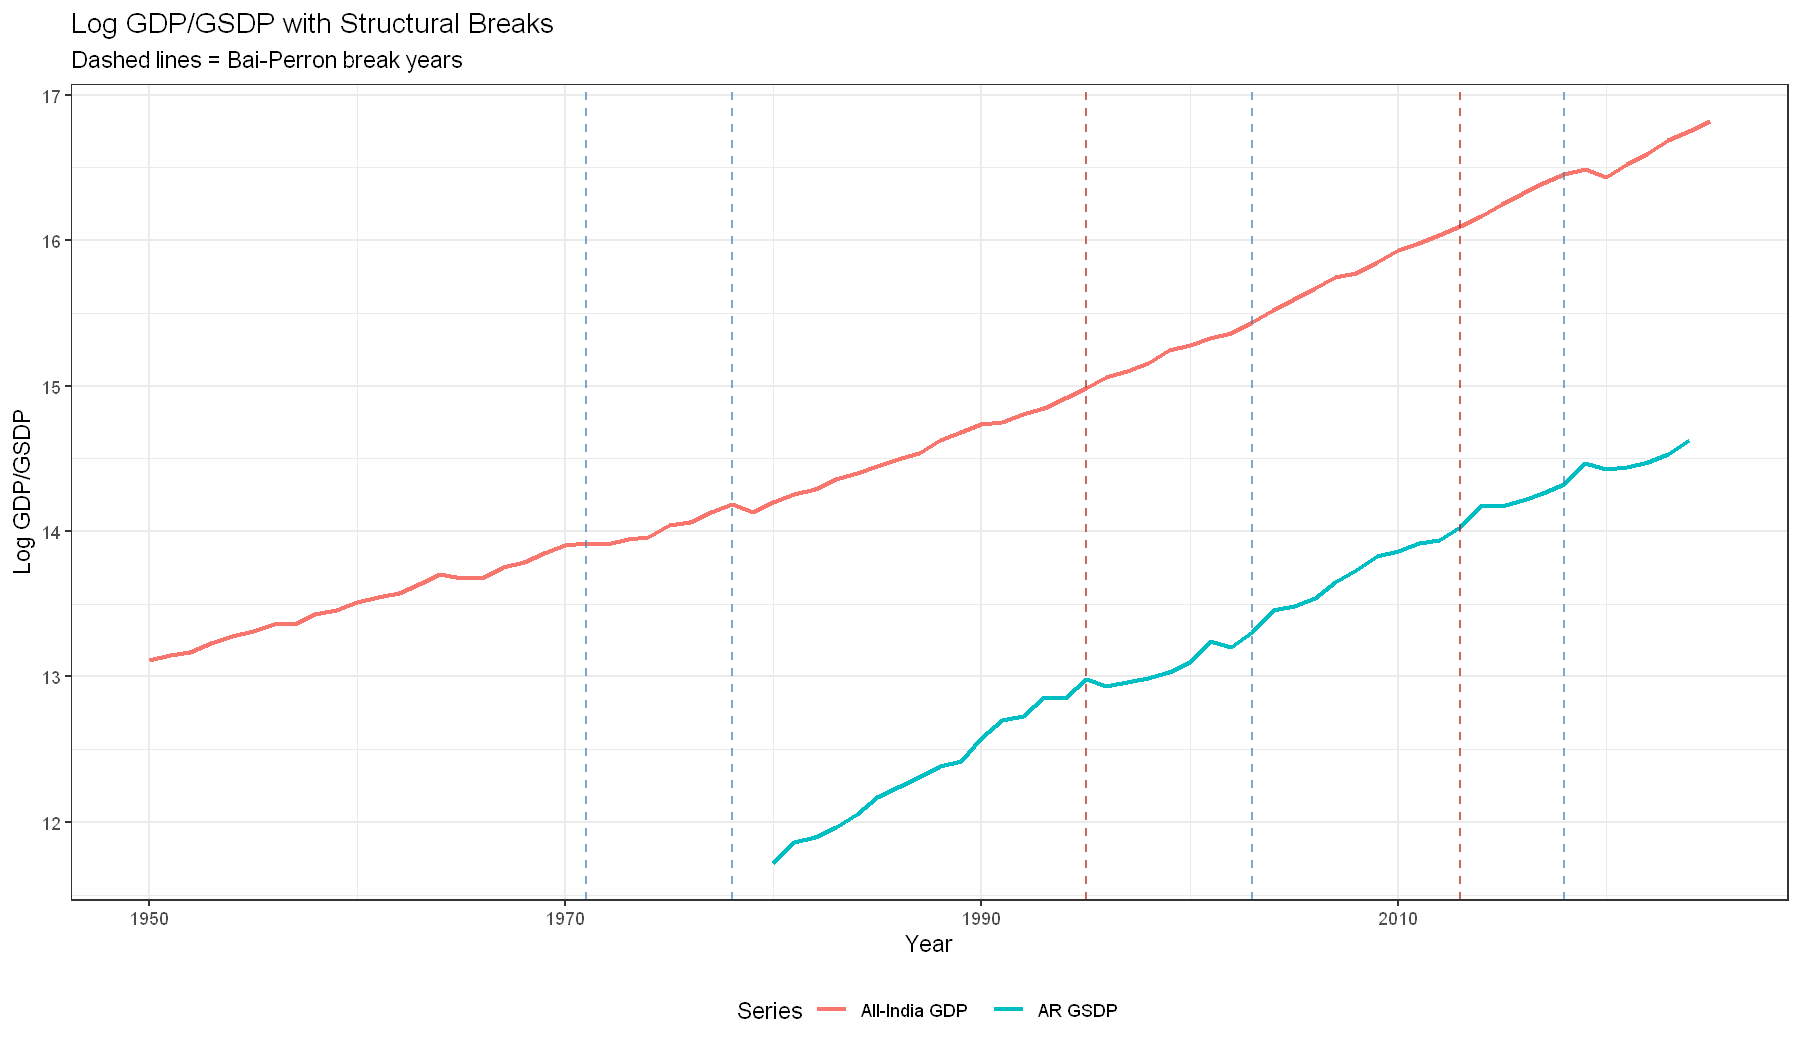

In [46]:
# Merge India and AR log GDP
dual <- merge(gdp_india[,c('NumYear','log_GDP')], ar_gdp[,c('NumYear','log_GSDP')], by='NumYear', all=TRUE)

p1 <- ggplot(dual, aes(x=NumYear)) +
  geom_line(aes(y=log_GDP, color='All-India GDP'), linewidth=1) +
  geom_line(aes(y=log_GSDP, color='AR GSDP'), linewidth=1) +
  geom_vline(xintercept=break_years_india, linetype='dashed', color='steelblue', alpha=0.7) +
  geom_vline(xintercept=break_years_ar, linetype='dashed', color='firebrick', alpha=0.7) +
  labs(title='Log GDP/GSDP with Structural Breaks', x='Year', y='Log GDP/GSDP',
       subtitle='Dashed lines = Bai-Perron break years', color='Series') +
  theme_bw() + theme(legend.position='bottom')

ggsave(file.path(FIG_DIR, 'fig1_log_gdp_breaks.png'), p1, width=10, height=6, dpi=300)
cat('Figure 1 saved:', file.exists(file.path(FIG_DIR, 'fig1_log_gdp_breaks.png')), '\n')
p1

### Figure 2 — AR Real GSDP with Structural Breaks

Figure 2 saved: TRUE 


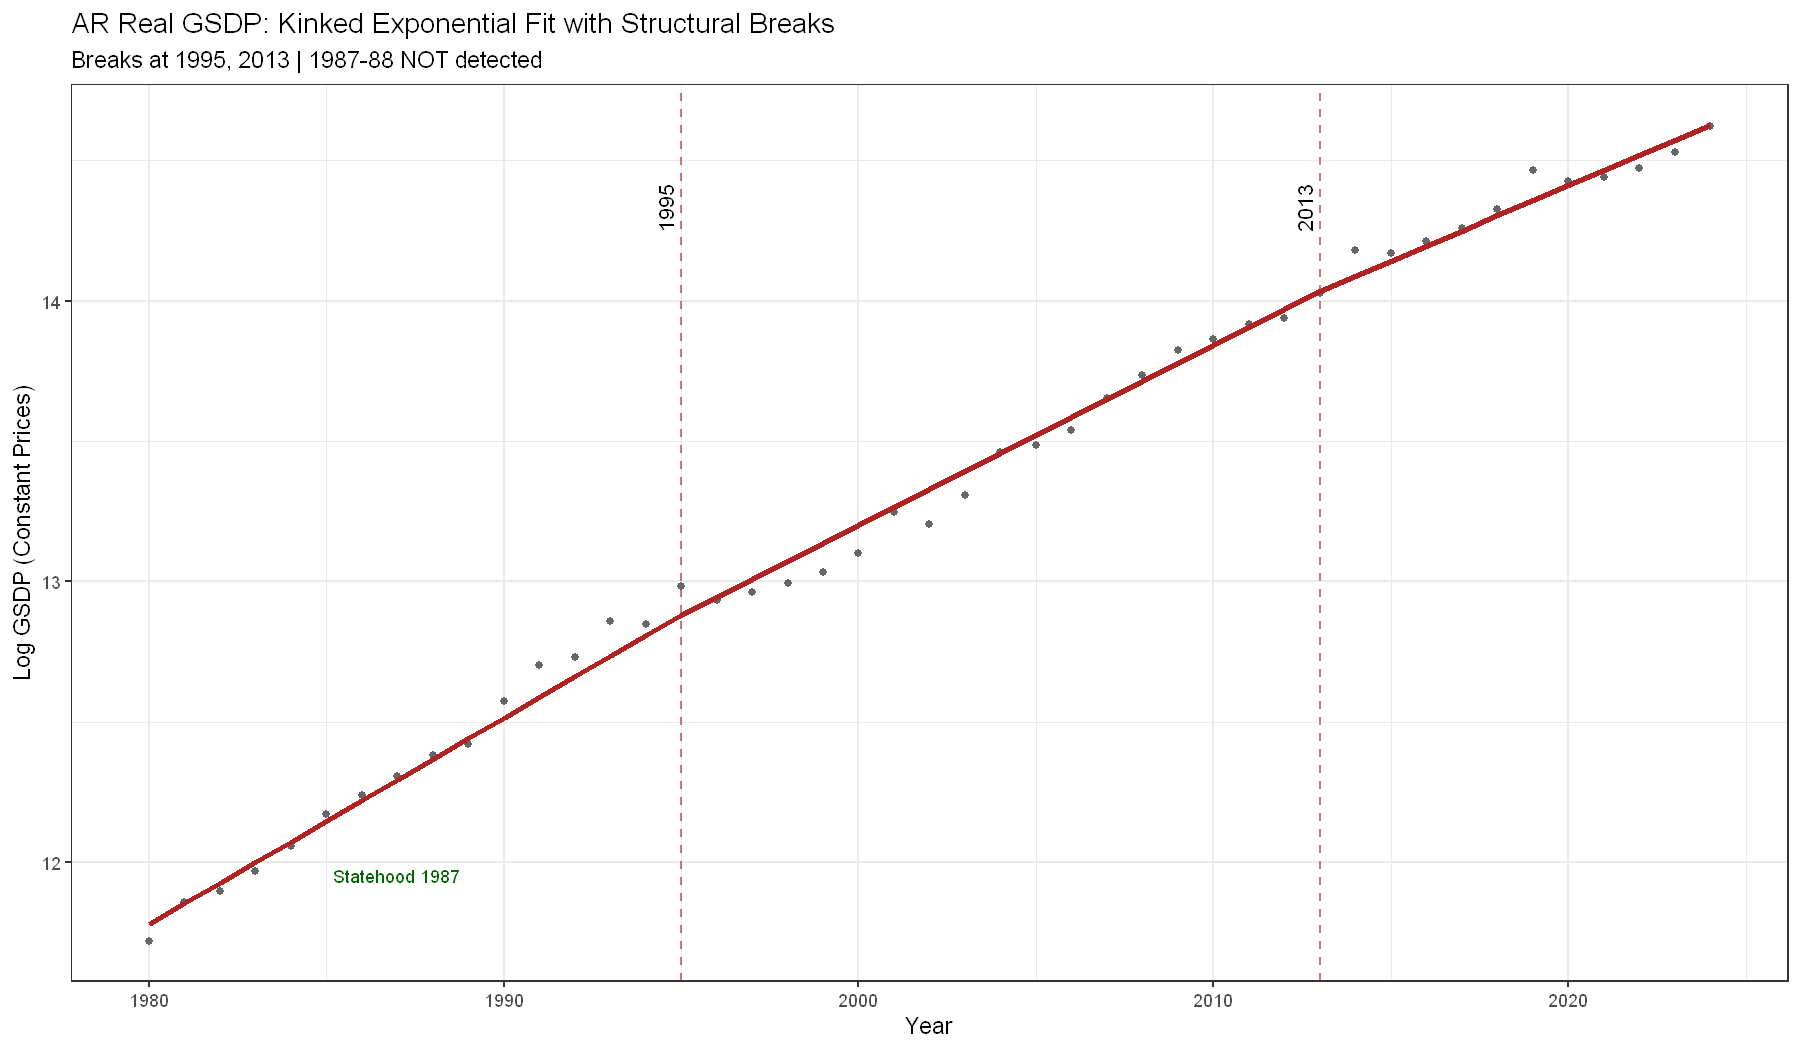

In [47]:
ar_fit <- data.frame(NumYear=ar_gdp$NumYear, log_GSDP=ar_gdp$log_GSDP, fitted=fitted(kinked_ar))

p2 <- ggplot(ar_fit, aes(x=NumYear)) +
  geom_point(aes(y=log_GSDP), color='grey40', size=1.5) +
  geom_line(aes(y=fitted), color='firebrick', linewidth=1.2) +
  geom_vline(xintercept=break_years_ar, linetype='dashed', color='firebrick', alpha=0.6) +
  annotate('text', x=break_years_ar, y=max(ar_fit$log_GSDP)*0.98,
           label=break_years_ar, angle=90, vjust=-0.5, size=3.5) +
  annotate('text', x=1987, y=min(ar_fit$log_GSDP)*1.02, label='Statehood 1987', color='darkgreen', size=3) +
  labs(title='AR Real GSDP: Kinked Exponential Fit with Structural Breaks',
       subtitle=sprintf('Breaks at %s | 1987-88 NOT detected', paste(break_years_ar, collapse=', ')),
       x='Year', y='Log GSDP (Constant Prices)') +
  theme_bw()

ggsave(file.path(FIG_DIR, 'fig2_ar_gsdp_breaks.png'), p2, width=10, height=6, dpi=300)
cat('Figure 2 saved:', file.exists(file.path(FIG_DIR, 'fig2_ar_gsdp_breaks.png')), '\n')
p2

### Figure 3 — Sectoral Shares in AR GSDP

Warning message:
"Removed 31 rows containing non-finite outside the scale range (`stat_align()`)."


Figure 3 saved: TRUE 


Warning message:
"Removed 31 rows containing non-finite outside the scale range (`stat_align()`)."


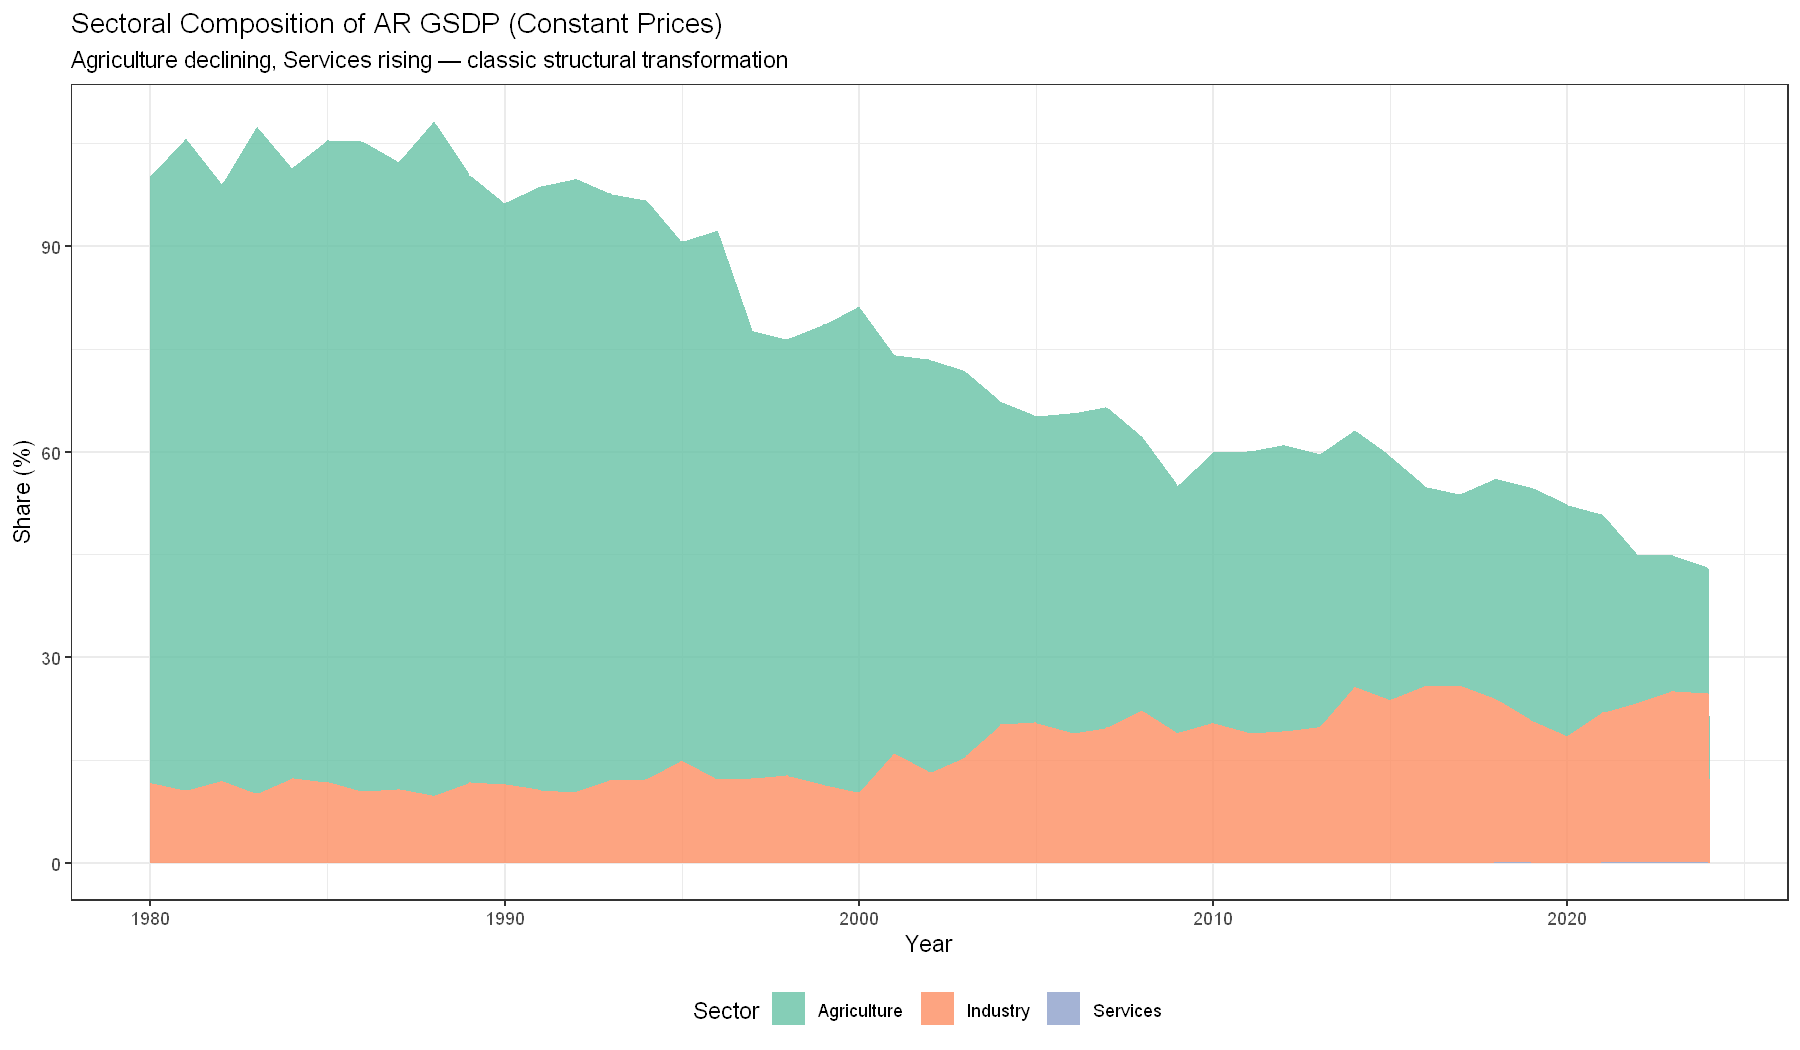

In [48]:
sect_long <- ar_gdp %>% select(NumYear, Agr_share, Ind_share, Srv_share) %>%
  pivot_longer(-NumYear, names_to='Sector', values_to='Share') %>%
  mutate(Sector = recode(Sector, Agr_share='Agriculture', Ind_share='Industry', Srv_share='Services'))

p3 <- ggplot(sect_long, aes(x=NumYear, y=Share, fill=Sector)) +
  geom_area(alpha=0.8) +
  scale_fill_manual(values=c('Agriculture'='#66c2a5','Industry'='#fc8d62','Services'='#8da0cb')) +
  labs(title='Sectoral Composition of AR GSDP (Constant Prices)',
       subtitle='Agriculture declining, Services rising — classic structural transformation',
       x='Year', y='Share (%)') +
  theme_bw() + theme(legend.position='bottom')

ggsave(file.path(FIG_DIR, 'fig3_sectoral_shares.png'), p3, width=10, height=6, dpi=300)
cat('Figure 3 saved:', file.exists(file.path(FIG_DIR, 'fig3_sectoral_shares.png')), '\n')
p3

### Figure 4 — AR Piecewise Fitted Growth

Figure 4 saved: TRUE 


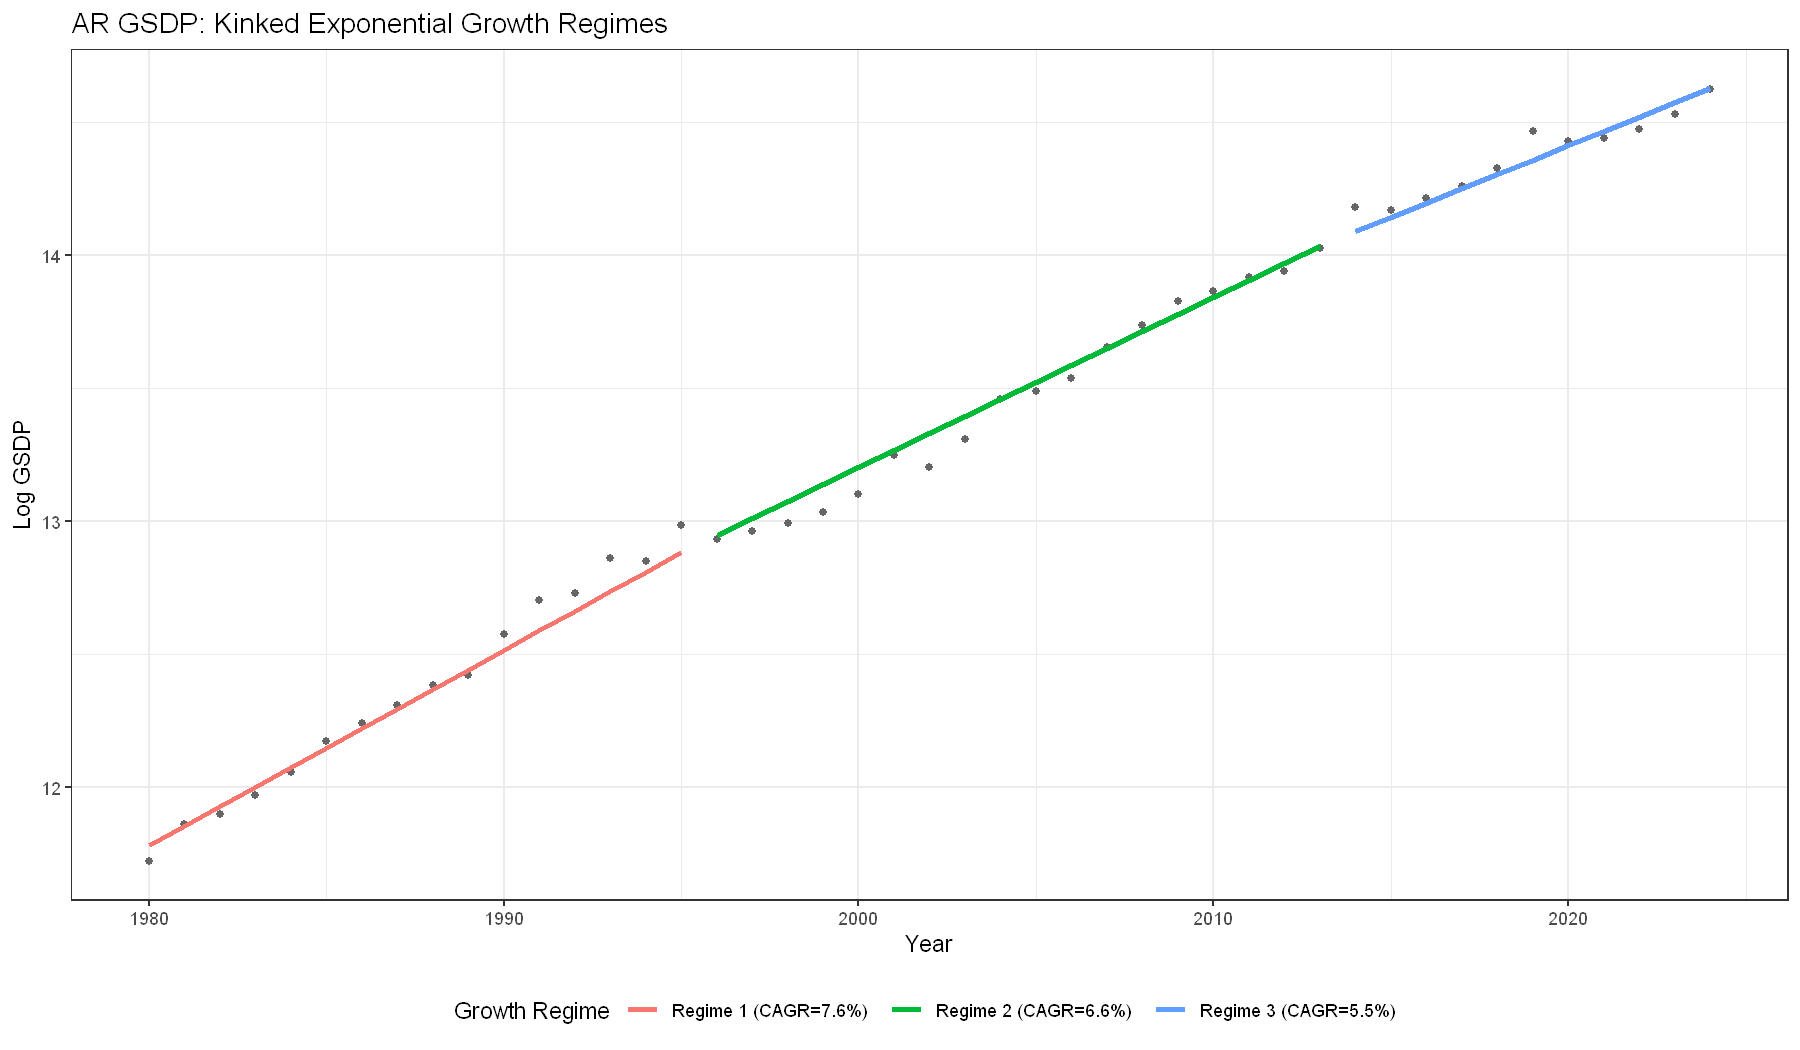

In [49]:
ar_fit$regime <- cut(ar_fit$NumYear,
  breaks=c(-Inf, break_years_ar, Inf),
  labels=paste0('Regime ', 1:(n_breaks_ar+1), ' (CAGR=', round((exp(growth_ar)-1)*100,1), '%)'))

p4 <- ggplot(ar_fit, aes(x=NumYear)) +
  geom_point(aes(y=log_GSDP), color='grey40', size=1.5) +
  geom_line(aes(y=fitted, color=regime), linewidth=1.3) +
  labs(title='AR GSDP: Kinked Exponential Growth Regimes',
       x='Year', y='Log GSDP', color='Growth Regime') +
  theme_bw() + theme(legend.position='bottom')

ggsave(file.path(FIG_DIR, 'fig4_ar_kinked_fit.png'), p4, width=10, height=6, dpi=300)
cat('Figure 4 saved:', file.exists(file.path(FIG_DIR, 'fig4_ar_kinked_fit.png')), '\n')
p4

### Figure 5 — Quarterly CPI Inflation: India vs AR

Figure 5 saved: TRUE 


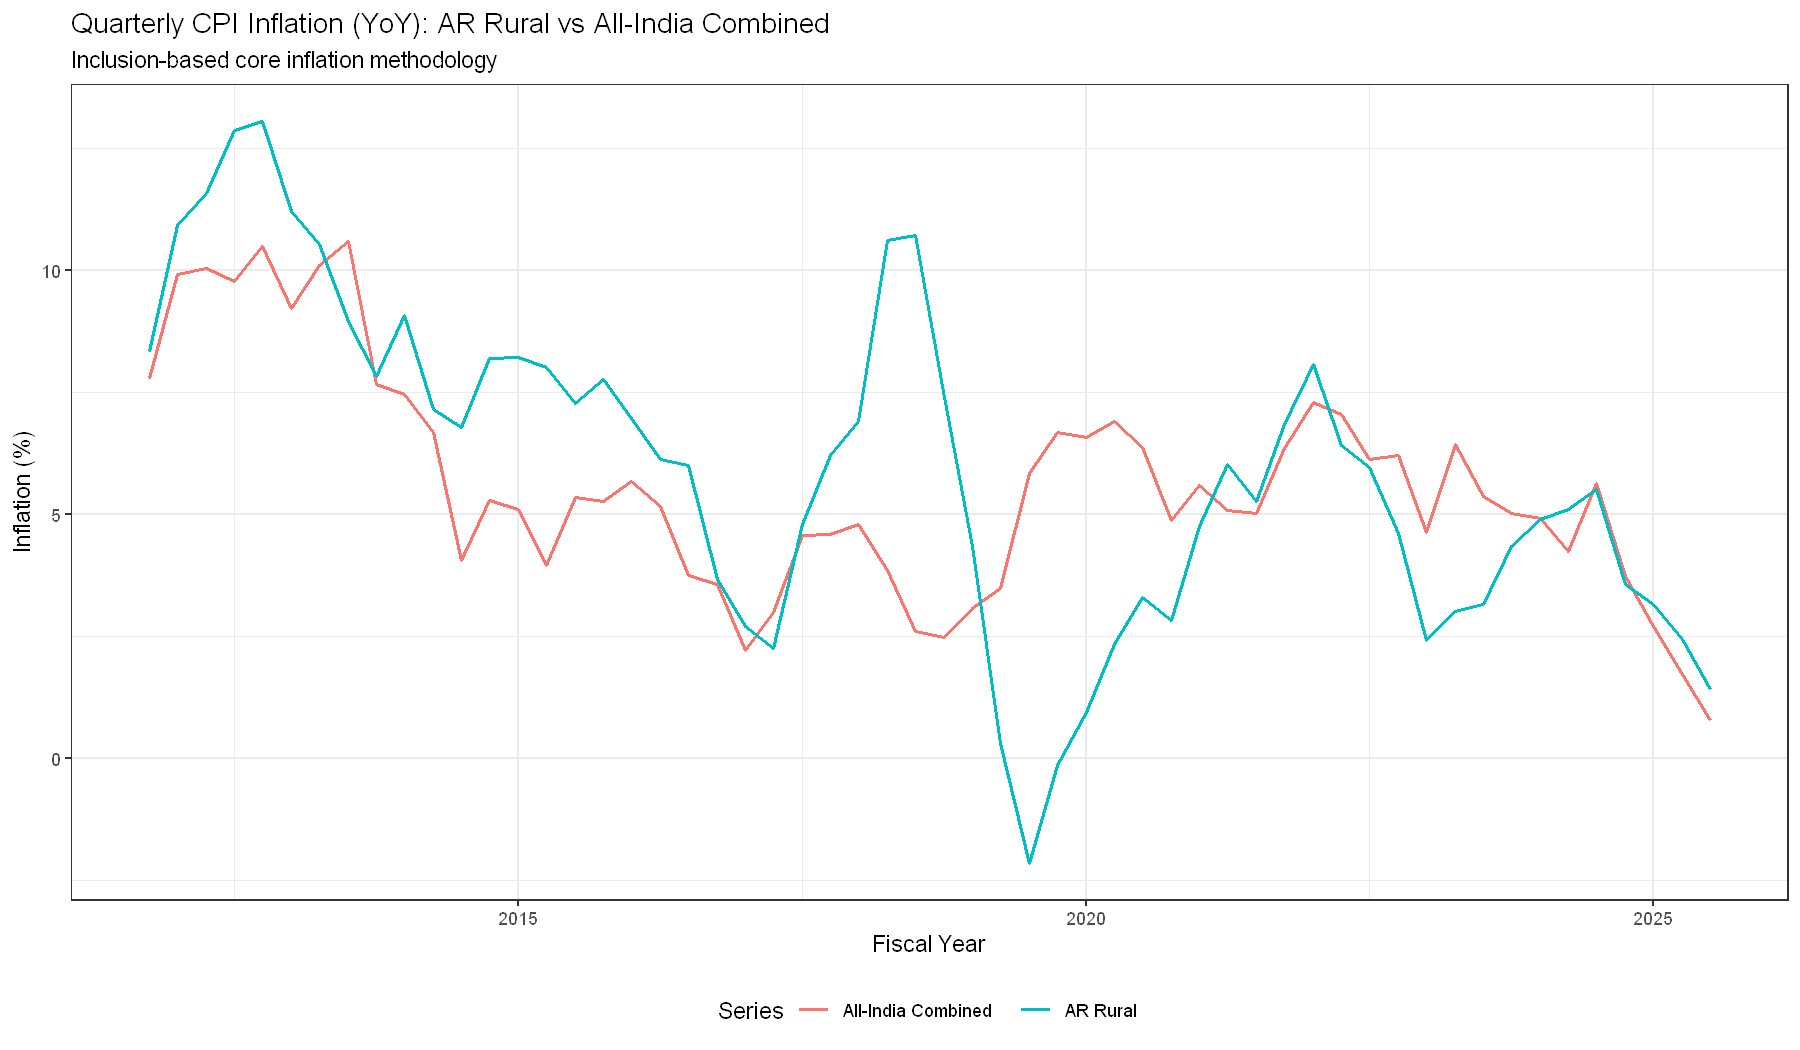

In [50]:
q_merged$time_idx <- q_merged$FY + (q_merged$FQ-1)/4

p5 <- ggplot(q_merged, aes(x=time_idx)) +
  geom_line(aes(y=inflation_combined, color='All-India Combined'), linewidth=0.8) +
  geom_line(aes(y=inflation_rural, color='AR Rural'), linewidth=0.8) +
  labs(title='Quarterly CPI Inflation (YoY): AR Rural vs All-India Combined',
       subtitle='Inclusion-based core inflation methodology',
       x='Fiscal Year', y='Inflation (%)', color='Series') +
  theme_bw() + theme(legend.position='bottom')

ggsave(file.path(FIG_DIR, 'fig5_quarterly_cpi.png'), p5, width=10, height=6, dpi=300)
cat('Figure 5 saved:', file.exists(file.path(FIG_DIR, 'fig5_quarterly_cpi.png')), '\n')
p5

### Figure 6 — Annual Headline vs Core Inflation

Warning message:
"Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`)."


Figure 6 saved: TRUE 


Warning message:
"Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`)."


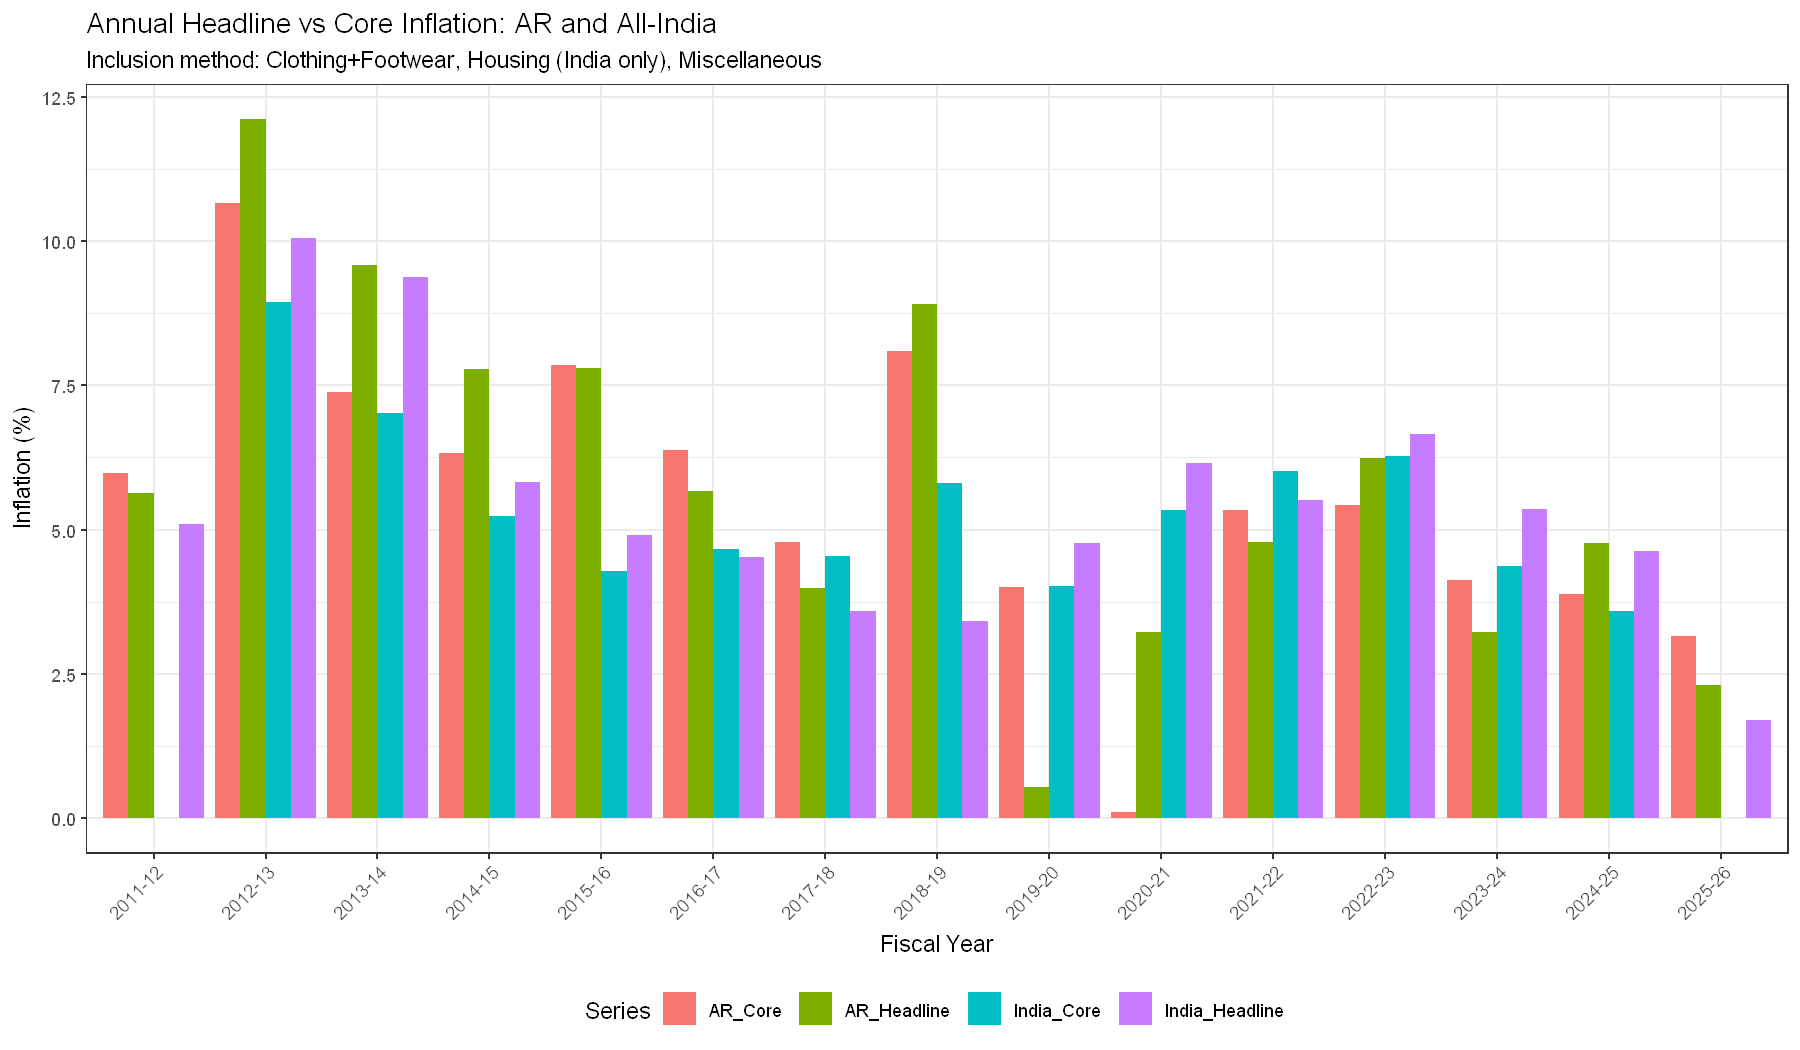

In [51]:
t4_long <- table4 %>% filter(!is.na(AR_Headline)) %>%
  pivot_longer(-FY_label, names_to='Series', values_to='Inflation')

p6 <- ggplot(t4_long, aes(x=FY_label, y=Inflation, fill=Series)) +
  geom_bar(stat='identity', position='dodge') +
  labs(title='Annual Headline vs Core Inflation: AR and All-India',
       subtitle='Inclusion method: Clothing+Footwear, Housing (India only), Miscellaneous',
       x='Fiscal Year', y='Inflation (%)') +
  theme_bw() + theme(axis.text.x=element_text(angle=45, hjust=1), legend.position='bottom')

ggsave(file.path(FIG_DIR, 'fig6_headline_core.png'), p6, width=10, height=6, dpi=300)
cat('Figure 6 saved:', file.exists(file.path(FIG_DIR, 'fig6_headline_core.png')), '\n')
p6

### Figure 7 — Sigma-Convergence

Figure 7 saved: TRUE 


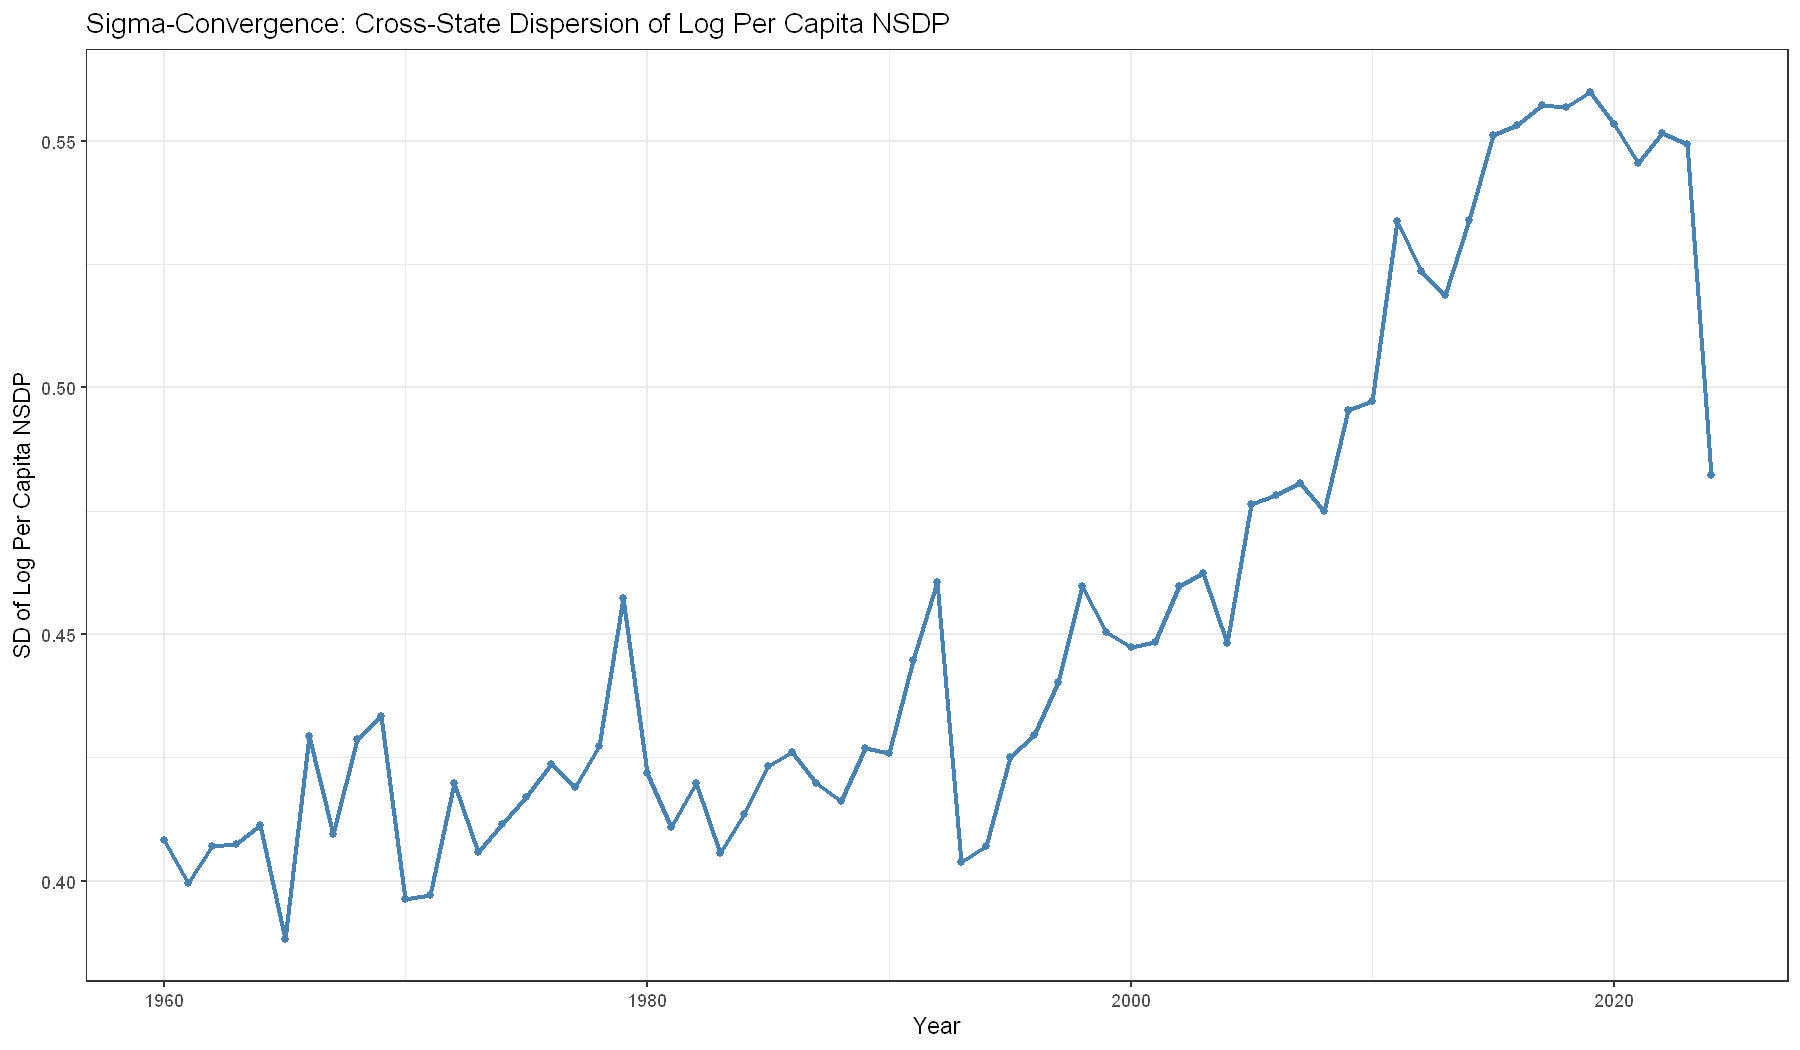

In [52]:
p7 <- ggplot(sigma_df, aes(x=Year, y=SD_log)) +
  geom_line(linewidth=1, color='steelblue') +
  geom_point(size=1.5, color='steelblue') +
  labs(title='Sigma-Convergence: Cross-State Dispersion of Log Per Capita NSDP',
       x='Year', y='SD of Log Per Capita NSDP') +
  theme_bw()

ggsave(file.path(FIG_DIR, 'fig7_sigma_convergence.png'), p7, width=10, height=6, dpi=300)
cat('Figure 7 saved:', file.exists(file.path(FIG_DIR, 'fig7_sigma_convergence.png')), '\n')
p7

### Figure 8 — Fiscal Dependence Ratio

Figure 8 saved: TRUE 


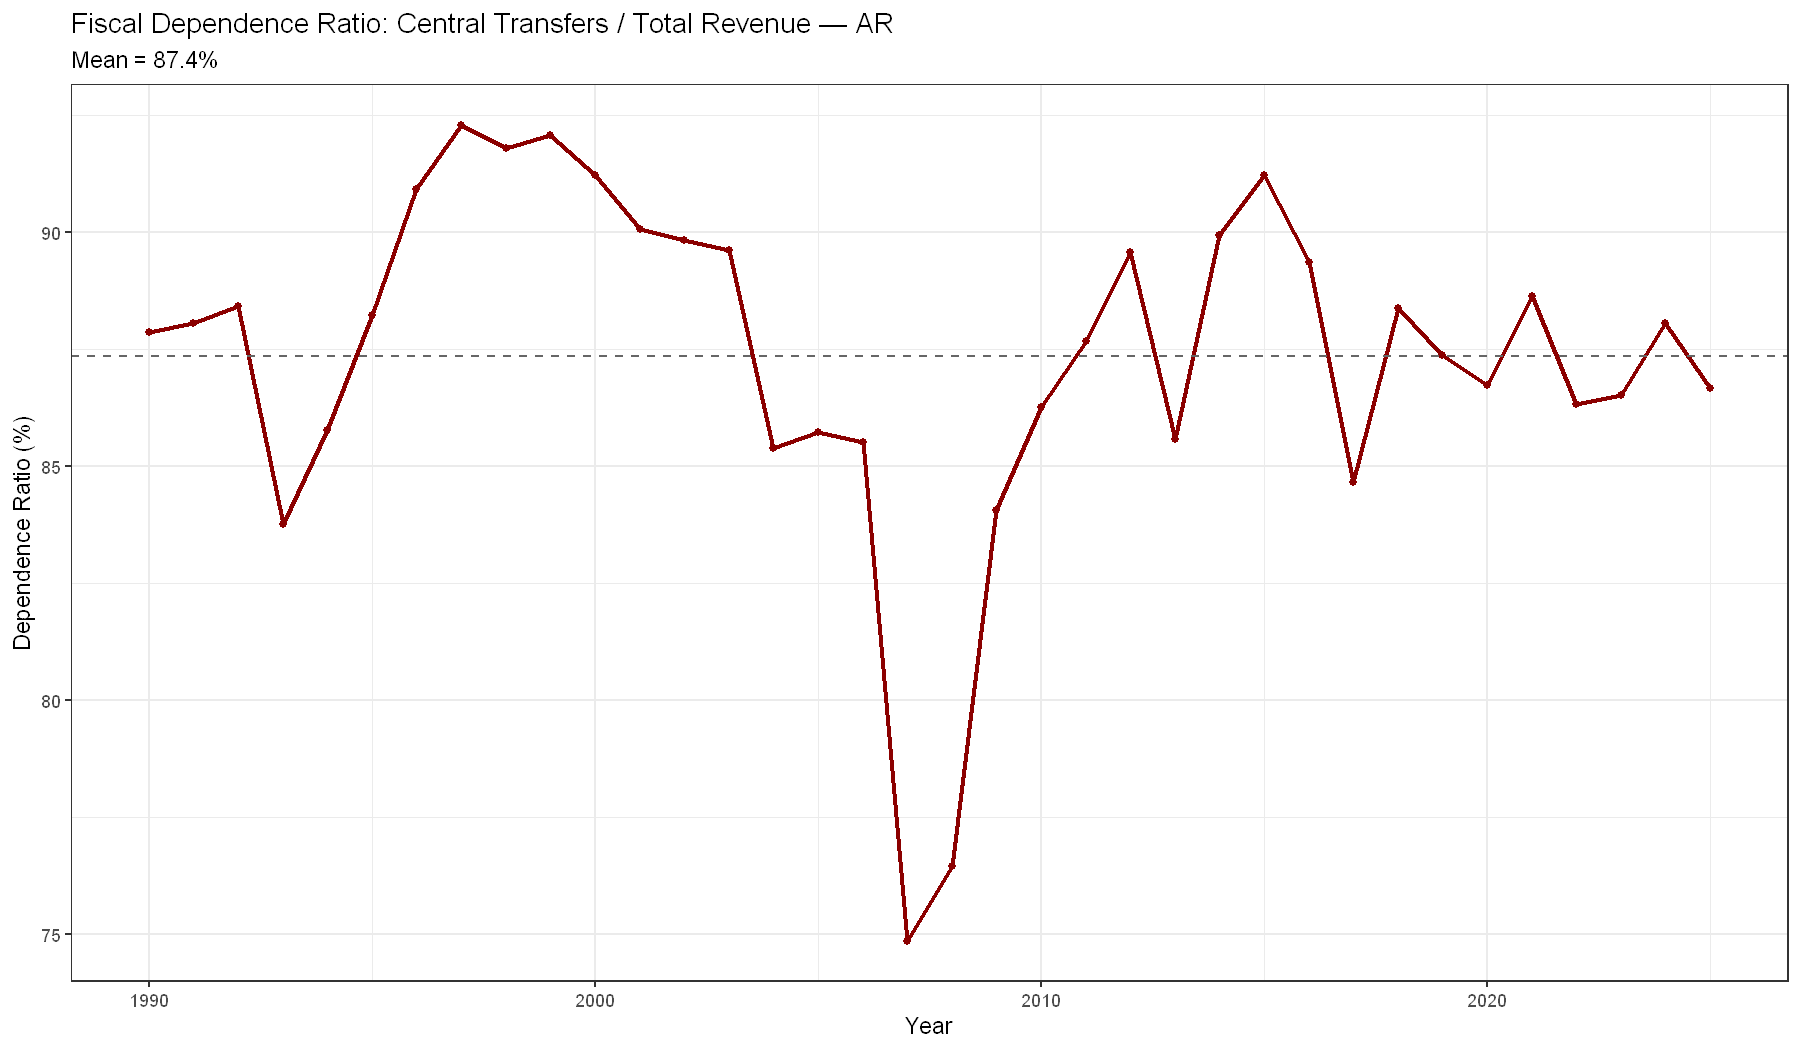

In [53]:
p8 <- ggplot(fisc_dep, aes(x=NumYear, y=DepRatio)) +
  geom_line(linewidth=1, color='darkred') +
  geom_point(size=1.5, color='darkred') +
  geom_hline(yintercept=mean(fisc_dep$DepRatio, na.rm=T), linetype='dashed', color='grey40') +
  labs(title='Fiscal Dependence Ratio: Central Transfers / Total Revenue — AR',
       subtitle=sprintf('Mean = %.1f%%', mean(fisc_dep$DepRatio, na.rm=T)),
       x='Year', y='Dependence Ratio (%)') +
  theme_bw()

ggsave(file.path(FIG_DIR, 'fig8_fiscal_dependence.png'), p8, width=10, height=6, dpi=300)
cat('Figure 8 saved:', file.exists(file.path(FIG_DIR, 'fig8_fiscal_dependence.png')), '\n')
p8

### Figure 9 — Revenue Surplus, Fiscal & Primary Balance as % GSDP

Figure 9 saved: TRUE 


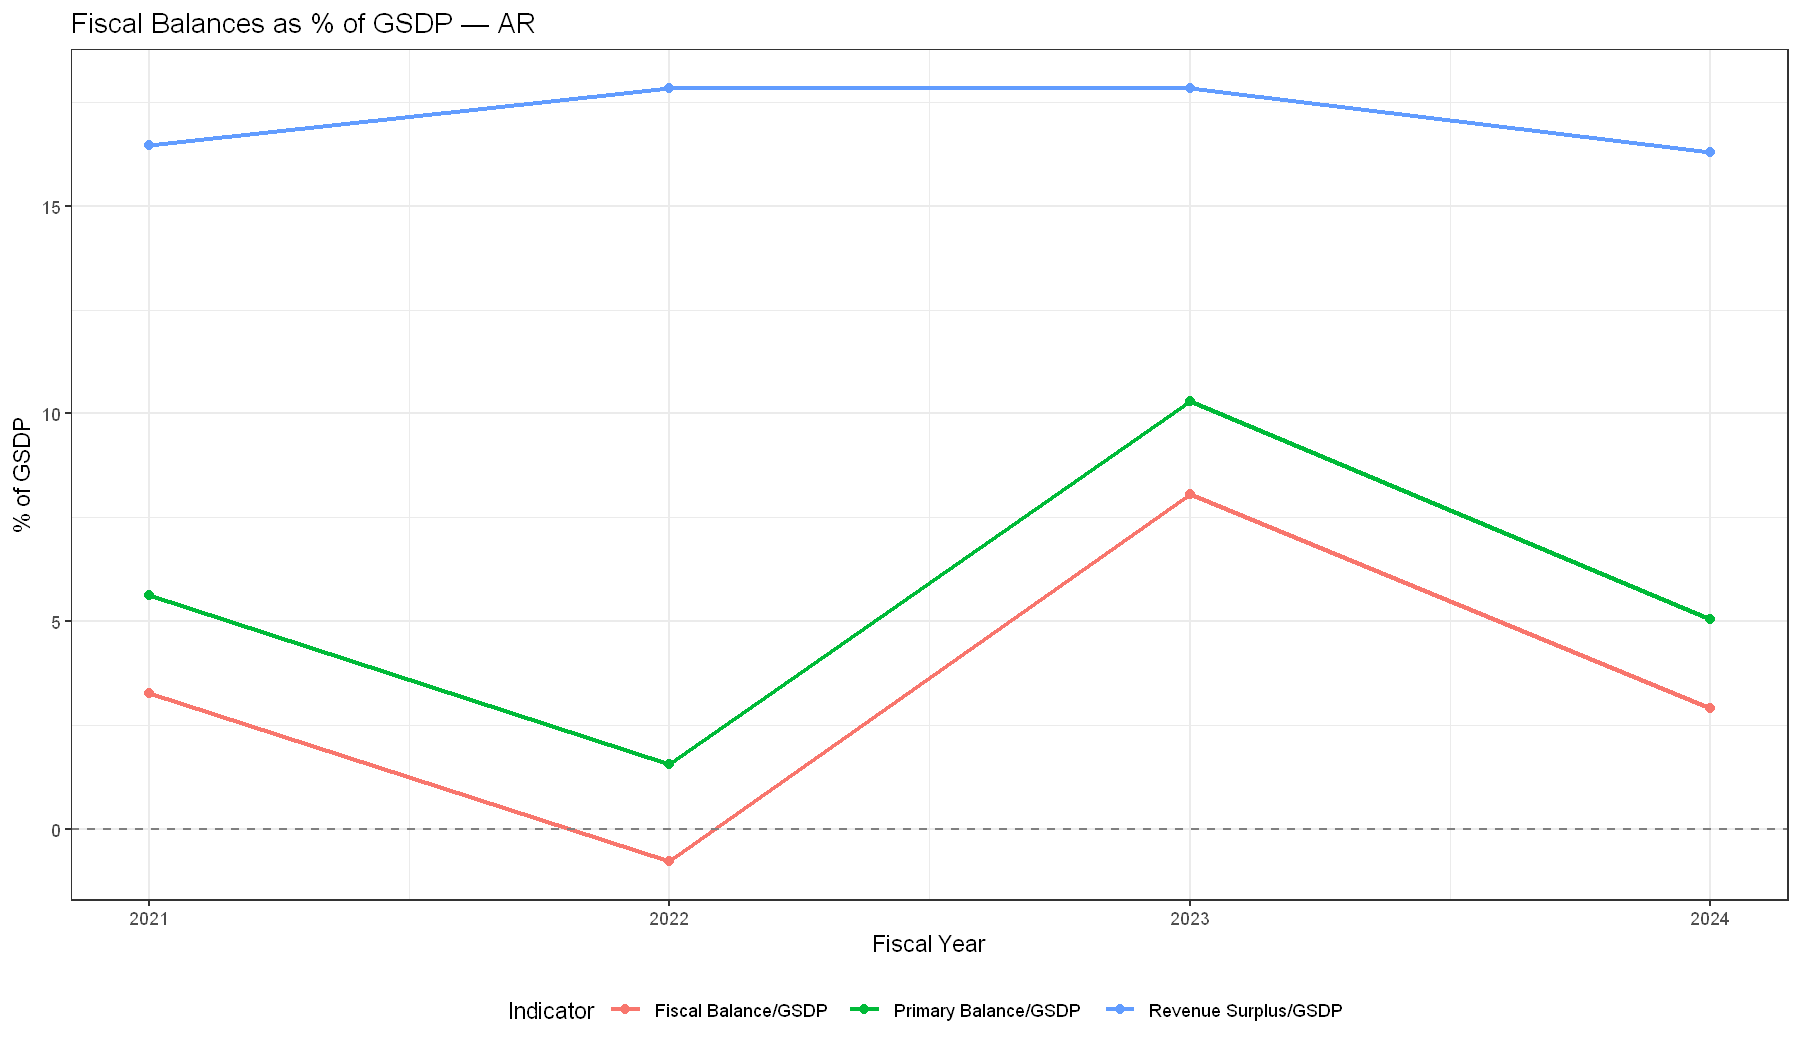

In [54]:
p9 <- ggplot(proj2, aes(x=Year)) +
  geom_line(aes(y=RevSurp_GSDP, color='Revenue Surplus/GSDP'), linewidth=1) +
  geom_line(aes(y=FiscBal_GSDP, color='Fiscal Balance/GSDP'), linewidth=1) +
  geom_line(aes(y=PrimBal_GSDP, color='Primary Balance/GSDP'), linewidth=1) +
  geom_point(aes(y=RevSurp_GSDP, color='Revenue Surplus/GSDP'), size=2) +
  geom_point(aes(y=FiscBal_GSDP, color='Fiscal Balance/GSDP'), size=2) +
  geom_point(aes(y=PrimBal_GSDP, color='Primary Balance/GSDP'), size=2) +
  geom_hline(yintercept=0, linetype='dashed', color='grey50') +
  labs(title='Fiscal Balances as % of GSDP — AR',
       x='Fiscal Year', y='% of GSDP', color='Indicator') +
  theme_bw() + theme(legend.position='bottom')

ggsave(file.path(FIG_DIR, 'fig9_fiscal_balances.png'), p9, width=10, height=6, dpi=300)
cat('Figure 9 saved:', file.exists(file.path(FIG_DIR, 'fig9_fiscal_balances.png')), '\n')
p9

### Figure 10 — Capital Outlay vs Interest Payments

Figure 10 saved: TRUE 


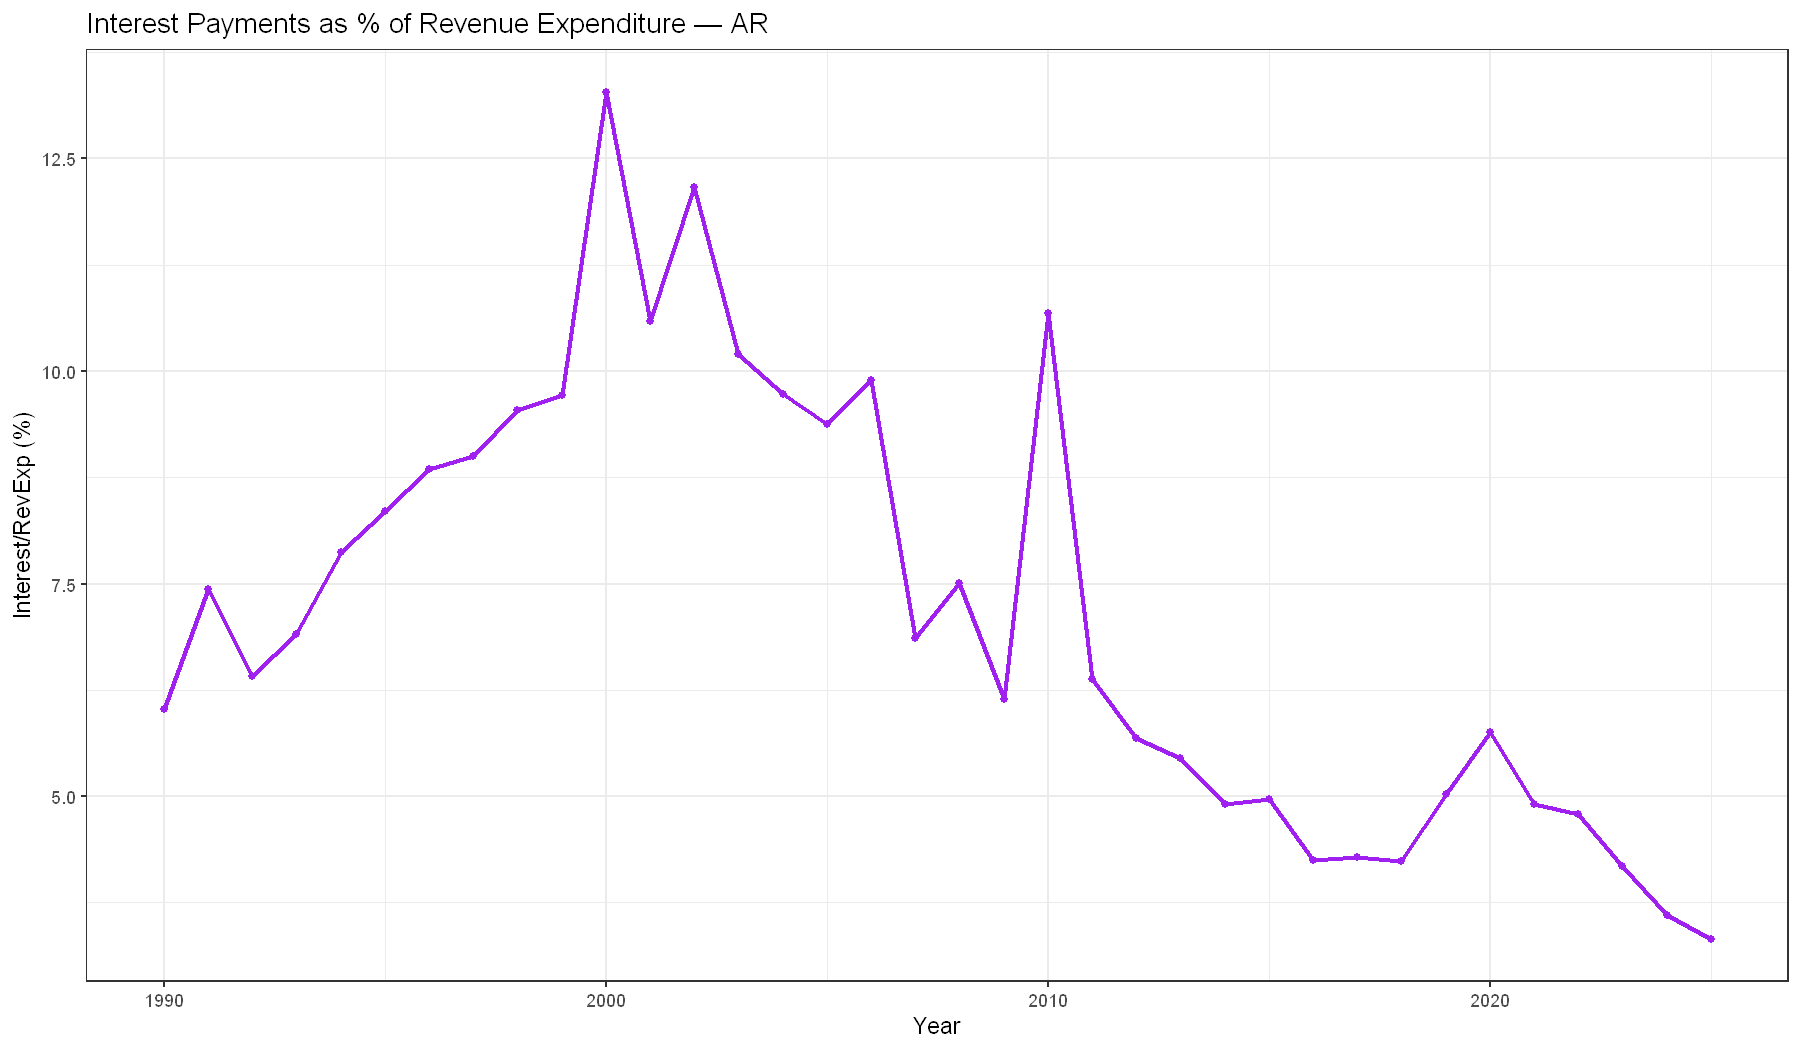

In [55]:
interest_all <- extract_sf('II.C.2: Interest Payments (i to iv)', 'Appendix-2')
names(interest_all) <- c('NumYear','Interest')
rev_exp_all2 <- rev_exp_all

int_ratio <- merge(interest_all, rev_exp_all2, by='NumYear')
int_ratio$IntRevExp <- int_ratio$Interest / int_ratio$RevExp * 100

p10 <- ggplot(int_ratio, aes(x=NumYear, y=IntRevExp)) +
  geom_line(linewidth=1, color='purple') +
  geom_point(size=1.5, color='purple') +
  labs(title='Interest Payments as % of Revenue Expenditure — AR',
       x='Year', y='Interest/RevExp (%)') +
  theme_bw()

ggsave(file.path(FIG_DIR, 'fig10_interest_ratio.png'), p10, width=10, height=6, dpi=300)
cat('Figure 10 saved:', file.exists(file.path(FIG_DIR, 'fig10_interest_ratio.png')), '\n')
p10

### Figure 11 — Own Revenue / Revenue Expenditure

Figure 11 saved: TRUE 


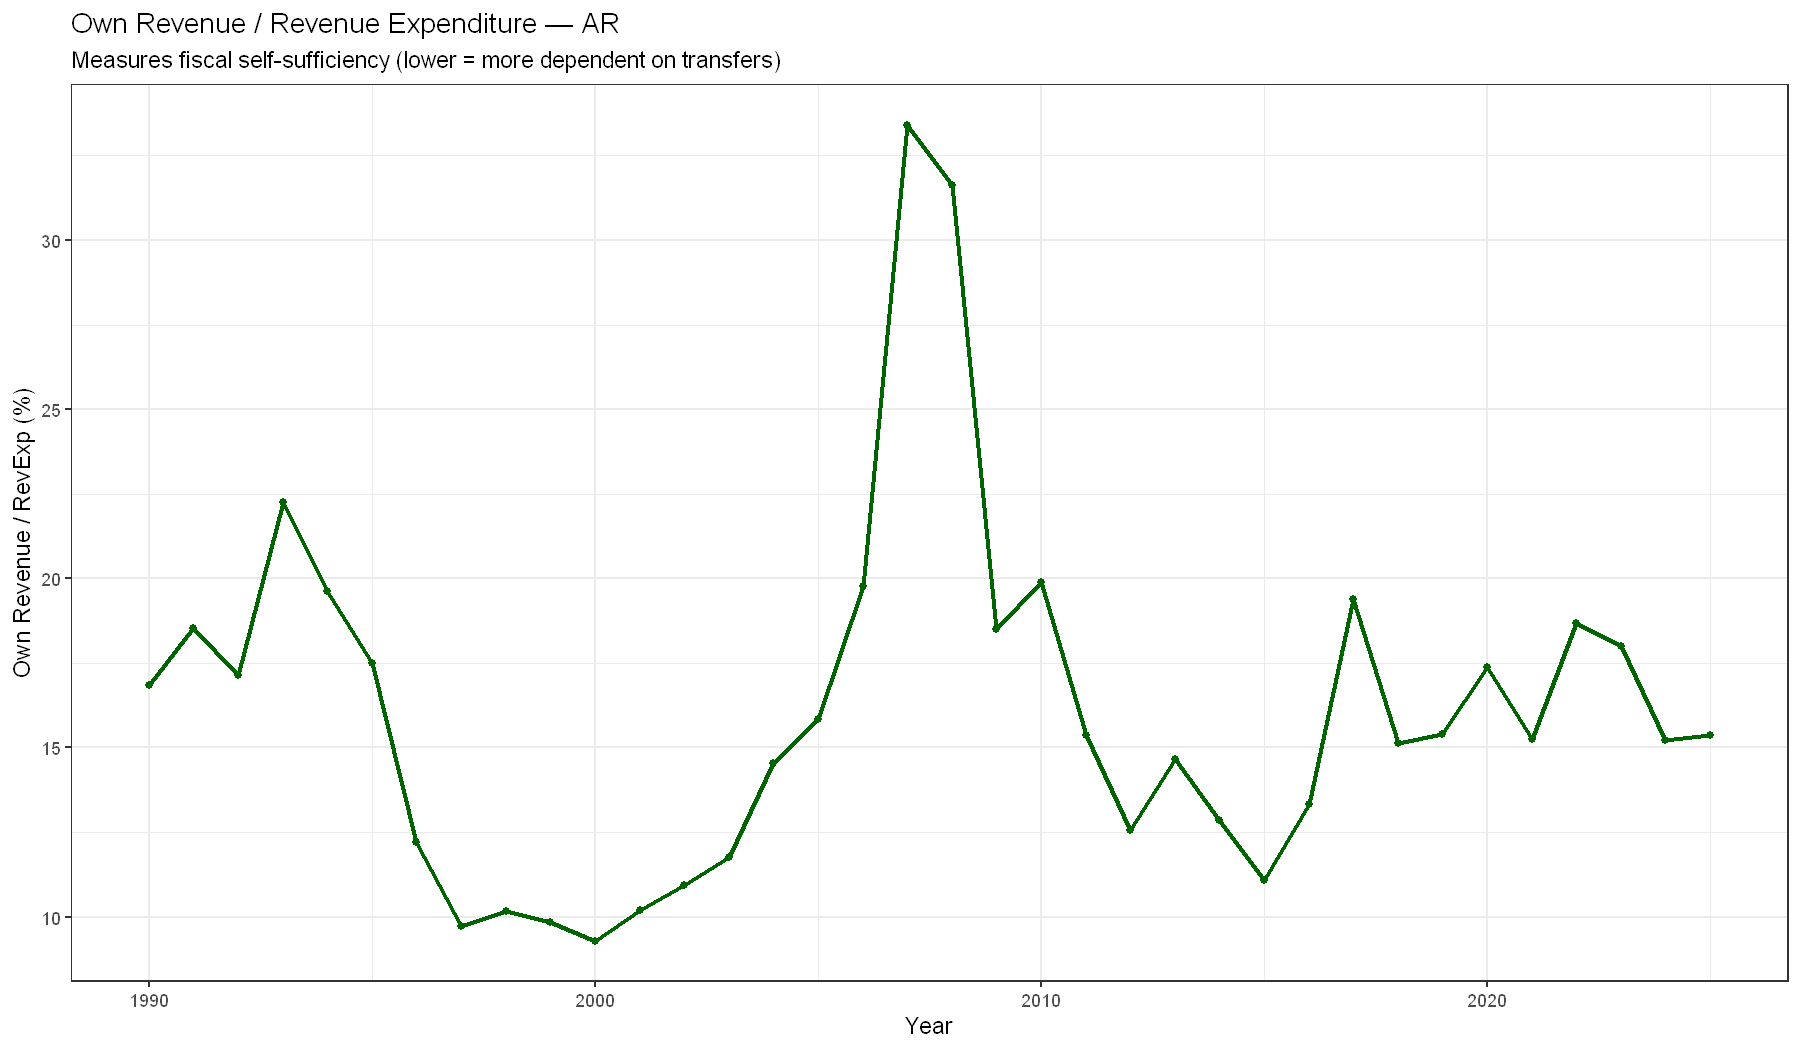

In [56]:
p11 <- ggplot(ext_fiscal, aes(x=NumYear, y=OwnRev_RevExp)) +
  geom_line(linewidth=1, color='darkgreen') +
  geom_point(size=1.5, color='darkgreen') +
  labs(title='Own Revenue / Revenue Expenditure — AR',
       subtitle='Measures fiscal self-sufficiency (lower = more dependent on transfers)',
       x='Year', y='Own Revenue / RevExp (%)') +
  theme_bw()

ggsave(file.path(FIG_DIR, 'fig11_own_revenue_ratio.png'), p11, width=10, height=6, dpi=300)
cat('Figure 11 saved:', file.exists(file.path(FIG_DIR, 'fig11_own_revenue_ratio.png')), '\n')
p11

### Verification — All Figures Saved

In [57]:
fig_files <- list.files(FIG_DIR, pattern='\\.png$', full.names=TRUE)
cat(sprintf('Total figures: %d\n', length(fig_files)))
for (f in fig_files) cat(sprintf('  %s: %s\n', basename(f), file.exists(f)))

Total figures: 11
  fig1_log_gdp_breaks.png: TRUE
  fig10_interest_ratio.png: TRUE
  fig11_own_revenue_ratio.png: TRUE
  fig2_ar_gsdp_breaks.png: TRUE
  fig3_sectoral_shares.png: TRUE
  fig4_ar_kinked_fit.png: TRUE
  fig5_quarterly_cpi.png: TRUE
  fig6_headline_core.png: TRUE
  fig7_sigma_convergence.png: TRUE
  fig8_fiscal_dependence.png: TRUE
  fig9_fiscal_balances.png: TRUE
